In [225]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import kurtosis
from scipy.fft import fft
from scipy.signal import welch

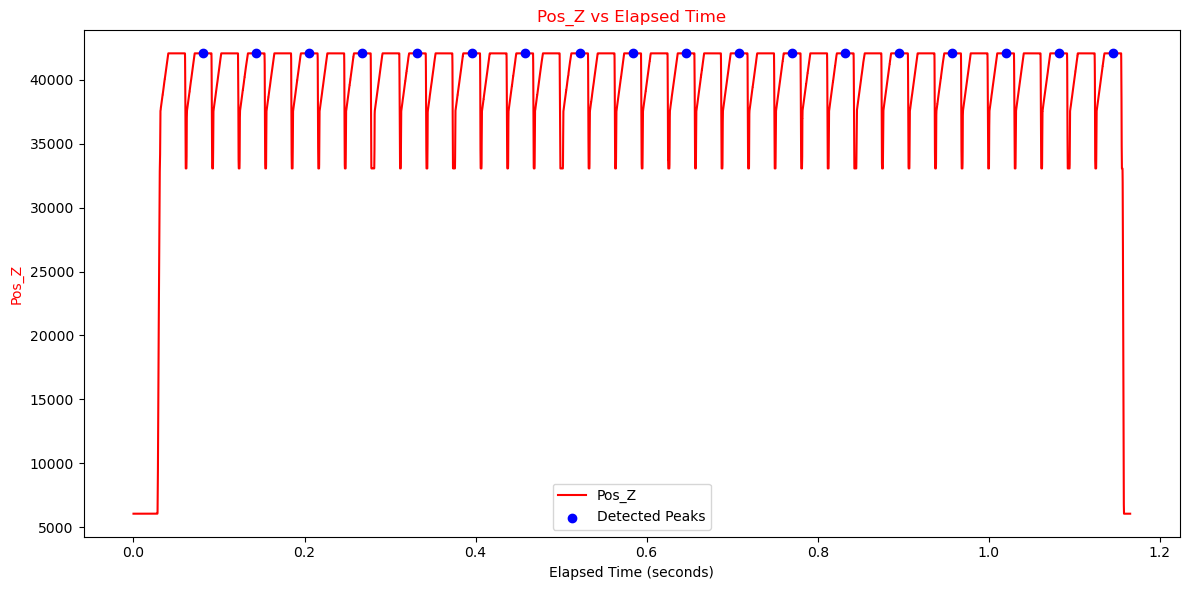

In [226]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load the dataset
d = pd.read_csv(r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\Good_tool_registry\registry_record_4.csv")

# Convert TimeStamp from numeric to datetime
d.loc[:, 'TimeStamp'] = pd.to_datetime(d['TimeStamp'], unit='ms')

# List of columns to plot
columns_to_plot = ['Pos_Z']

# Calculate the elapsed time since the recording started
d.loc[:, 'Elapsed_Time'] = (d['TimeStamp'] - d['TimeStamp'].iloc[0]).dt.total_seconds()

# Plot the data with the elapsed time
fig, ax = plt.subplots(figsize=(12, 6))  # Single axis since len(columns_to_plot) == 1

# Plot the column
col = columns_to_plot[0]
ax.plot(d['Elapsed_Time'], d[col], label=col, color='red')
ax.set_title(f'{col} vs Elapsed Time', color='red')
ax.set_ylabel(col, color='red')

# Detect and mark repeating patterns
signal = d[col].to_numpy()
peaks, _ = find_peaks(signal, height=np.mean(signal), distance=1000)  # Adjust `distance` based on expected repetition

# Mark peaks on the plot
ax.scatter(d['Elapsed_Time'].iloc[peaks], signal[peaks], color='blue', label='Detected Peaks', zorder=5)
ax.legend()

# Set common x-axis label
plt.xlabel('Elapsed Time (seconds)')
plt.tight_layout()
plt.show()


In [227]:
directories_ciss = [r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\CISS_RAW\Good_CISSRawData_LogFiles_4", r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\CISS_RAW\Good_CISSRawData_LogFiles_5",
                   r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\CISS_RAW\Worn_CISSRawData_LogFiles_1",
                   r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\CISS_RAW\Worn_CISSRawData_LogFiles_2",r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\CISS_RAW\Worn_CISSRawData_LogFiles_3"]
directories_registry = [r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\Worn_tool_registry",r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\Good_tool_registry"]

In [228]:
import os
import pandas as pd

def get_ciss_raw(directories):
    """
    Reads and concatenates CSV files from multiple directories, ensuring data is labeled.
    
    Parameters:
        directories (list): List of directory paths containing the CSV files.
        
    Returns:
        pd.DataFrame: Concatenated DataFrame with labeled data.
    """
    dataframes = []
    
    for directory in directories:
        for filename in os.listdir(directory):
            if filename.endswith(".csv"):
                file_path = os.path.join(directory, filename)
                try:
                    # Read the CSV file
                    df = pd.read_csv(file_path, skiprows=8, encoding='Windows-1252')
                    
                    # Process the data
                    df = df.iloc[:-1]  # Remove the last row
                    df.rename(columns={"Unix TimeStamp (ms)": "TimeStamp", "Data / x_axis": "x_axis"}, inplace=True)
                    df["TimeStamp"] = pd.to_numeric(df["TimeStamp"]).astype(float)
                    df.drop(columns=["Measurement Type"], inplace=True)
                    
                    # Assign label based on directory name
                    if "Worn" in directory:
                        df["Label"] = 1  # Worn tool
                    elif "Good" in directory:
                        df["Label"] = 0  # Good tool
                    else:
                        raise ValueError(f"Unknown label for directory: {directory}")
                    
                    # Append to list of dataframes
                    dataframes.append(df)
                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")
    
    # Concatenate all dataframes
    if dataframes:
        combined_df = pd.concat(dataframes, ignore_index=True)
        return combined_df
    else:
        raise ValueError("No dataframes were created. Check the directories and files.")

# Example usage
def main():
    directories_ciss = [
        r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\CISS_RAW\Good_CISSRawData_LogFiles_4",
        r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\CISS_RAW\Good_CISSRawData_LogFiles_5",
        r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\CISS_RAW\Worn_CISSRawData_LogFiles_1",
        r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\CISS_RAW\Worn_CISSRawData_LogFiles_2",
        r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\CISS_RAW\Worn_CISSRawData_LogFiles_3"
    ]

    try:
        labeled_data = get_ciss_raw(directories_ciss)
        print("Data successfully labeled and loaded!")
        print(labeled_data.head())

        # Return the labeled dataframe for further processing
        return labeled_data
    except Exception as e:
        print(f"Error: {e}")
        return None

# Store the output in a variable for use in feature extraction or other programs
dataframe_ciss = main()


Data successfully labeled and loaded!
      TimeStamp  x_axis  y_axis  z_axis  Label
0  1.733413e+12    25.0  -999.0     9.0      0
1  1.733413e+12    19.0  -995.0    -7.0      0
2  1.733413e+12    15.0  -985.0     3.0      0
3  1.733413e+12    25.0  -999.0     5.0      0
4  1.733413e+12    19.0  -993.0     7.0      0


In [229]:
import os
import pandas as pd

def get_registry_record(directories):
    """
    Reads and concatenates CSV files from multiple directories, ensuring data is labeled.

    Parameters:
        directories (list): List of directory paths containing the CSV files.

    Returns:
        pd.DataFrame: Concatenated DataFrame with labeled data.
    """
    dataframes = []

    for directory in directories:
        for filename in os.listdir(directory):
            if filename.endswith(".csv"):
                file_path = os.path.join(directory, filename)
                try:
                    # Read the CSV file
                    df = pd.read_csv(file_path)

                    # Process the data
                    df.rename(columns={"Unnamed: 0": "TimeStamp"}, inplace=True)
                    df["TimeStamp"] = df["TimeStamp"].astype(str).str.replace(".", "", regex=False).str[:13]
                    df["TimeStamp"] = pd.to_numeric(df["TimeStamp"]).astype(float)
                    df.drop(columns=[
                        "WinPCNCRunning", "CurrentJobProgress", "CurrentJobTimeMin", 
                        "CurrentJobTimeSec", "CurrentJobCommandNo", "CurrentSpdOvr", "State"
                    ], inplace=True)

                    # Assign label based on directory name
                    if "Worn" in directory:
                        df["Label"] = 1  # Worn tool
                    elif "Good" in directory:
                        df["Label"] = 0  # Good tool
                    else:
                        raise ValueError(f"Unknown label for directory: {directory}")

                    # Append to list of dataframes
                    dataframes.append(df)
                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    # Concatenate all dataframes
    if dataframes:
        combined_df = pd.concat(dataframes, ignore_index=True)
        return combined_df
    else:
        raise ValueError("No dataframes were created. Check the directories and files.")

# Example usage:
# Define directories for registry data
directories_registry = [
    r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\Worn_tool_registry",
    r"C:\Users\srite\Documents\SEML_25\seml_2025-ciss_develop-data\data\Good_tool_registry"
]

# Load and label registry data
def main():
    try:
        registry_data = get_registry_record(directories_registry)
        print("Registry data successfully labeled and loaded!")
        print(registry_data.head())

        # Return the labeled dataframe for feature extraction
        return registry_data
    except Exception as e:
        print(f"Error: {e}")

# Store the output in a variable for further use
dataframe_registry = main()

Registry data successfully labeled and loaded!
      TimeStamp    Pos_X     Pos_Y  Pos_Z  Label
0  1.733408e+12  31975.0  231487.0    0.0      1
1  1.733408e+12  31975.0  231487.0    0.0      1
2  1.733408e+12  31975.0  231487.0    0.0      1
3  1.733408e+12  31975.0  231487.0    0.0      1
4  1.733408e+12  31975.0  231487.0    0.0      1


In [230]:

dataframe_ciss = dataframe_ciss.sort_values("TimeStamp", ascending=True)

dataframe_registry = dataframe_registry.sort_values("TimeStamp", ascending=True)

In [231]:
dataframe_all = pd.merge_asof(dataframe_ciss, dataframe_registry, on="TimeStamp", direction="nearest")

In [232]:
dataframe_all

,TimeStamp,x_axis,y_axis,z_axis,Label_x,Pos_X,Pos_Y,Pos_Z,Label_y
0,1.733408e+12,21.0,-989.0,5.0,1,31975.0,231487.0,0.0,1
1,1.733408e+12,11.0,-987.0,0.0,1,31975.0,231487.0,0.0,1
2,1.733408e+12,21.0,-989.0,0.0,1,31975.0,231487.0,0.0,1
3,1.733408e+12,11.0,-985.0,7.0,1,31975.0,231487.0,0.0,1
4,1.733408e+12,23.0,-989.0,-1.0,1,31975.0,231487.0,0.0,1
...,...,...,...,...,...,...,...,...,...
12374310,1.733416e+12,27.0,-985.0,9.0,0,31975.0,231487.0,6062.0,0
12374311,1.733416e+12,19.0,-999.0,0.0,0,31975.0,231487.0,6062.0,0
12374312,1.733416e+12,15.0,-995.0,9.0,0,31975.0,231487.0,6062.0,0
12374313,1.733416e+12,11.0,-1003.0,5.0,0,31975.0,231487.0,6062.0,0


In [233]:
# Delete all the data in TimeStamp where the position of the milling tool was above the metal plate
peak_threshold = 0.975 * dataframe_all["Pos_Z"].max()
dataframe_all = dataframe_all[dataframe_all["Pos_Z"] >= peak_threshold]

C:\Users\srite\AppData\Local\Temp\ipykernel_4820\2096914359.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_all.loc[:, 'TimeStamp'] = pd.to_datetime(dataframe_all['TimeStamp'], unit='ms')
C:\Users\srite\AppData\Local\Temp\ipykernel_4820\2096914359.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_all.loc[:, 'Elapsed_Time'] = (dataframe_all['TimeStamp'] - dataframe_all['TimeStamp'].iloc[0]).dt.total_seconds()


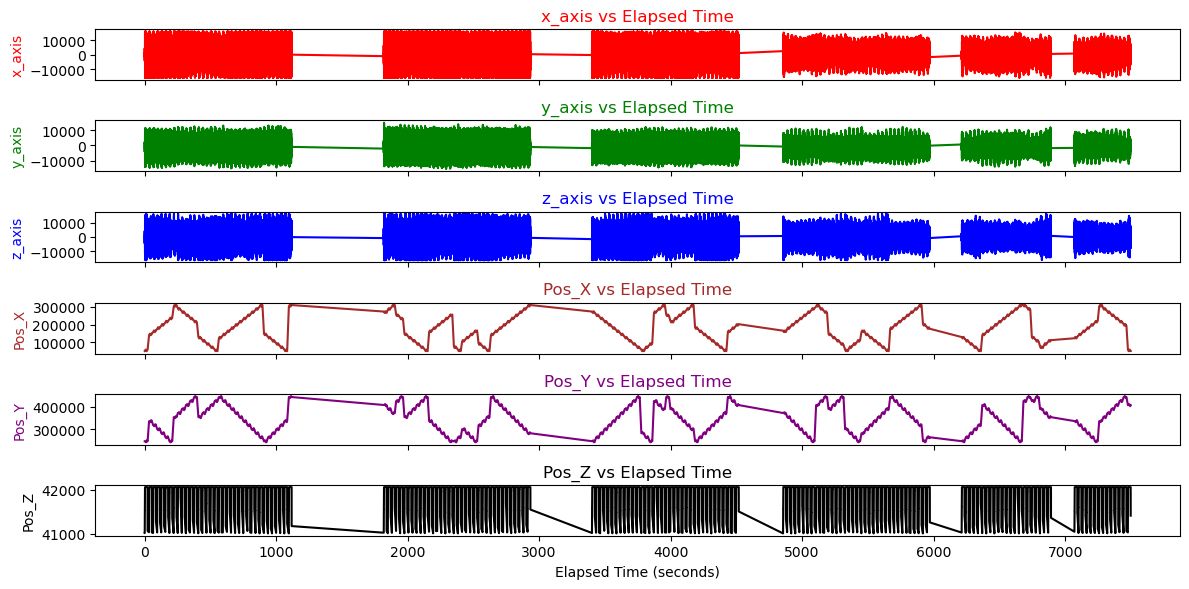

In [234]:
# Convert TimeStamp from numeric to datetime
dataframe_all.loc[:, 'TimeStamp'] = pd.to_datetime(dataframe_all['TimeStamp'], unit='ms')

# List of columns to plot
columns_to_plot = ['x_axis', 'y_axis', 'z_axis', 'Pos_X', 'Pos_Y', 'Pos_Z']

# Calculate the elapsed time since the recording started
dataframe_all.loc[:, 'Elapsed_Time'] = (dataframe_all['TimeStamp'] - dataframe_all['TimeStamp'].iloc[0]).dt.total_seconds()

# Plot the data with the elapsed time
fig, axes = plt.subplots(len(columns_to_plot), 1, figsize=(12, 6), sharex=True)
colors = ['red', 'green', 'blue', 'brown', 'purple', 'black']

# Plot each column
for ax, col, color in zip(axes, columns_to_plot, colors):
    ax.plot(dataframe_all['Elapsed_Time'], dataframe_all[col], label=col, color=color)
    ax.set_title(f'{col} vs Elapsed Time', color=color)  # Optional: Title color matches line
    ax.set_ylabel(col, color=color)  # Optional: Y-axis label matches color

# Set common x-axis label
plt.xlabel('Elapsed Time (seconds)')
plt.tight_layout()
plt.show()


C:\Users\srite\AppData\Local\Temp\ipykernel_4820\3660959243.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_all['TimeStamp'] = dataframe_all['TimeStamp'].astype('int64') // 10**6  # Convert datetime to Unix ms if needed
C:\Users\srite\AppData\Local\Temp\ipykernel_4820\3660959243.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_all['Relative_TimeStamp'] = dataframe_all['TimeStamp'] - dataframe_all['TimeStamp'].iloc[0]


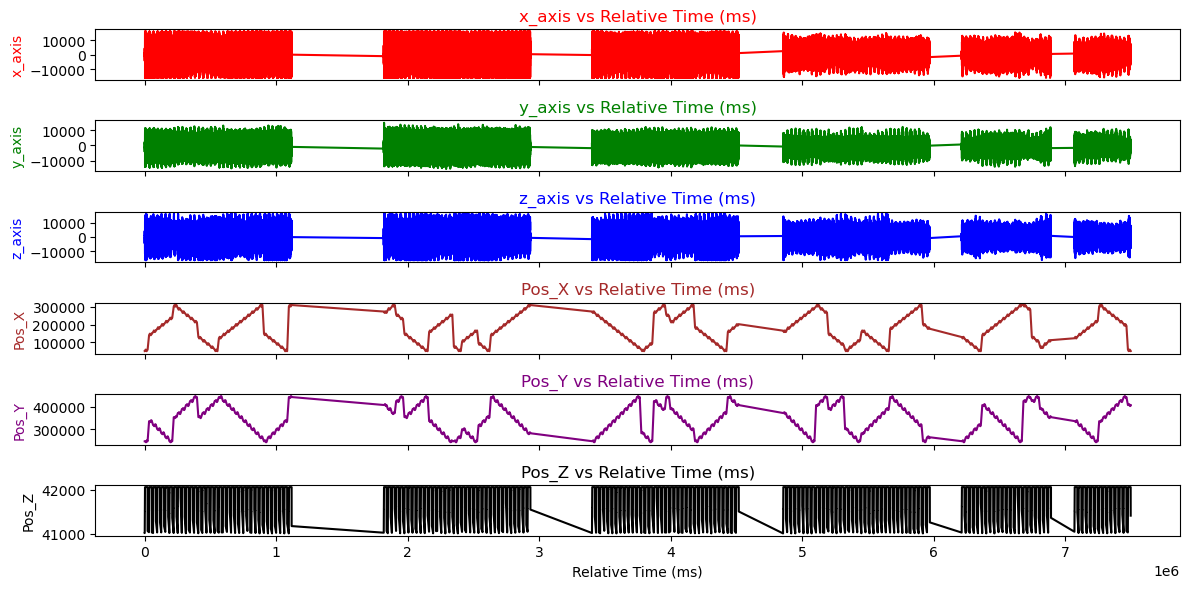

In [235]:
# Ensure 'TimeStamp' is in numeric Unix timestamp format (in milliseconds)
if pd.api.types.is_datetime64_any_dtype(dataframe_all['TimeStamp']):
    dataframe_all['TimeStamp'] = dataframe_all['TimeStamp'].astype('int64') // 10**6  # Convert datetime to Unix ms if needed

# Calculate Relative_TimeStamp (relative to the first timestamp)
dataframe_all['Relative_TimeStamp'] = dataframe_all['TimeStamp'] - dataframe_all['TimeStamp'].iloc[0]

# List of columns to plot
columns_to_plot = ['x_axis', 'y_axis', 'z_axis', 'Pos_X', 'Pos_Y', 'Pos_Z']

# Plot the data with the relative timestamps
fig, axes = plt.subplots(len(columns_to_plot), 1, figsize=(12, 6), sharex=True)
colors = ['red', 'green', 'blue', 'brown', 'purple', 'black']

# Plot each column
for ax, col, color in zip(axes, columns_to_plot, colors):
    ax.plot(dataframe_all['Relative_TimeStamp'], dataframe_all[col], label=col, color=color)
    ax.set_title(f'{col} vs Relative Time (ms)', color=color)  # Optional: Title color matches line
    ax.set_ylabel(col, color=color)  # Optional: Y-axis label matches color

# Set common x-axis label
plt.xlabel('Relative Time (ms)')
plt.tight_layout()
plt.show()


In [236]:
dataframe_all

,TimeStamp,x_axis,y_axis,z_axis,Label_x,Pos_X,Pos_Y,Pos_Z,Label_y,Elapsed_Time,Relative_TimeStamp
90400,1733408460800,1059.0,-1481.0,671.0,1,50575.0,244987.0,41021.0,1,0.00,0
90401,1733408460800,-1118.0,-1885.0,650.0,1,50575.0,244987.0,41021.0,1,0.00,0
90402,1733408460800,-220.0,-1270.0,212.0,1,50575.0,244987.0,41021.0,1,0.00,0
90403,1733408460800,798.0,-534.0,-601.0,1,50575.0,244987.0,41021.0,1,0.00,0
90404,1733408460800,1057.0,-610.0,1577.0,1,50575.0,244987.0,41021.0,1,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...
12346775,1733415959360,-495.0,44.0,1118.0,0,50575.0,406987.0,41415.0,0,7498.56,7498560
12346776,1733415959360,-111.0,-905.0,-1895.0,0,50575.0,406987.0,41415.0,0,7498.56,7498560
12346777,1733415959360,1114.0,-1214.0,1602.0,0,50575.0,406987.0,41415.0,0,7498.56,7498560
12346778,1733415959360,-837.0,-1665.0,-1036.0,0,50575.0,406987.0,41415.0,0,7498.56,7498560


In [237]:
dataframe_all.columns

Index(['TimeStamp', 'x_axis', 'y_axis', 'z_axis', 'Label_x', 'Pos_X', 'Pos_Y',
       'Pos_Z', 'Label_y', 'Elapsed_Time', 'Relative_TimeStamp'],
      dtype='object')

In [238]:
# Drop columns for acceleration features, without modifying dataframe_all
dataframe_raw = dataframe_all.drop(columns=["x_axis", "y_axis", "z_axis"])

# Drop columns for position features, without modifying dataframe_all
dataframe_reg = dataframe_all.drop(columns=["Pos_X", "Pos_Y", "Pos_Z"])

# Verify the results
print("DataFrame for Acceleration Data:")
print(dataframe_raw.head())

print("\nDataFrame for Position Data:")
print(dataframe_reg.head())


DataFrame for Acceleration Data:
           TimeStamp  Label_x    Pos_X     Pos_Y    Pos_Z  Label_y  \
90400  1733408460800        1  50575.0  244987.0  41021.0        1   
90401  1733408460800        1  50575.0  244987.0  41021.0        1   
90402  1733408460800        1  50575.0  244987.0  41021.0        1   
90403  1733408460800        1  50575.0  244987.0  41021.0        1   
90404  1733408460800        1  50575.0  244987.0  41021.0        1   

       Elapsed_Time  Relative_TimeStamp  
90400           0.0                   0  
90401           0.0                   0  
90402           0.0                   0  
90403           0.0                   0  
90404           0.0                   0  

DataFrame for Position Data:
           TimeStamp  x_axis  y_axis  z_axis  Label_x  Label_y  Elapsed_Time  \
90400  1733408460800  1059.0 -1481.0   671.0        1        1           0.0   
90401  1733408460800 -1118.0 -1885.0   650.0        1        1           0.0   
90402  1733408460800  -2

In [239]:
print(dataframe_reg.columns)
print(dataframe_raw.columns)

Index(['TimeStamp', 'x_axis', 'y_axis', 'z_axis', 'Label_x', 'Label_y',
       'Elapsed_Time', 'Relative_TimeStamp'],
      dtype='object')
Index(['TimeStamp', 'Label_x', 'Pos_X', 'Pos_Y', 'Pos_Z', 'Label_y',
       'Elapsed_Time', 'Relative_TimeStamp'],
      dtype='object')


In [240]:
dataframe_reg

,TimeStamp,x_axis,y_axis,z_axis,Label_x,Label_y,Elapsed_Time,Relative_TimeStamp
90400,1733408460800,1059.0,-1481.0,671.0,1,1,0.00,0
90401,1733408460800,-1118.0,-1885.0,650.0,1,1,0.00,0
90402,1733408460800,-220.0,-1270.0,212.0,1,1,0.00,0
90403,1733408460800,798.0,-534.0,-601.0,1,1,0.00,0
90404,1733408460800,1057.0,-610.0,1577.0,1,1,0.00,0
...,...,...,...,...,...,...,...,...
12346775,1733415959360,-495.0,44.0,1118.0,0,0,7498.56,7498560
12346776,1733415959360,-111.0,-905.0,-1895.0,0,0,7498.56,7498560
12346777,1733415959360,1114.0,-1214.0,1602.0,0,0,7498.56,7498560
12346778,1733415959360,-837.0,-1665.0,-1036.0,0,0,7498.56,7498560


In [241]:

# Drop column based on partial match
columns_to_drop = [col for col in dataframe_reg.columns if 'Label_y' in col]
dataframe_reg_1 = dataframe_reg.drop(columns=columns_to_drop)

# Rename 'Label_x' to 'Label'
dataframe_reg_1 = dataframe_reg_1.rename(columns={'Label_x': 'Label'})

# Verify the changes
print(dataframe_reg_1.columns)

# Drop column based on partial match
columns_to_drop = [col for col in dataframe_raw.columns if 'Label_y' in col]
dataframe_raw_1 = dataframe_raw.drop(columns=columns_to_drop)

# Rename 'Label_x' to 'Label'
dataframe_raw_1 = dataframe_raw_1.rename(columns={'Label_x': 'Label'})

# Verify the changes
print(dataframe_raw_1.columns)

Index(['TimeStamp', 'x_axis', 'y_axis', 'z_axis', 'Label', 'Elapsed_Time',
       'Relative_TimeStamp'],
      dtype='object')
Index(['TimeStamp', 'Label', 'Pos_X', 'Pos_Y', 'Pos_Z', 'Elapsed_Time',
       'Relative_TimeStamp'],
      dtype='object')


In [242]:
dataframe_reg_1


,TimeStamp,x_axis,y_axis,z_axis,Label,Elapsed_Time,Relative_TimeStamp
90400,1733408460800,1059.0,-1481.0,671.0,1,0.00,0
90401,1733408460800,-1118.0,-1885.0,650.0,1,0.00,0
90402,1733408460800,-220.0,-1270.0,212.0,1,0.00,0
90403,1733408460800,798.0,-534.0,-601.0,1,0.00,0
90404,1733408460800,1057.0,-610.0,1577.0,1,0.00,0
...,...,...,...,...,...,...,...
12346775,1733415959360,-495.0,44.0,1118.0,0,7498.56,7498560
12346776,1733415959360,-111.0,-905.0,-1895.0,0,7498.56,7498560
12346777,1733415959360,1114.0,-1214.0,1602.0,0,7498.56,7498560
12346778,1733415959360,-837.0,-1665.0,-1036.0,0,7498.56,7498560


In [309]:
import numpy as np
import pandas as pd
from scipy.signal import stft, welch
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt

# Function to compute Wavelet Transform
def compute_wavelet_transform(signal):
    scales = np.arange(1, 64)
    signal_downsampled = signal[::10]
    coefficients, _ = pywt.cwt(signal_downsampled, scales, 'cmor1.5-1.0')
    return np.mean(np.abs(coefficients))

# Function to extract features for a single axis
def extract_features(signal):
    features = {}
    signal_array = signal.to_numpy()

    # Statistical Metrics
    features['xaxis_mean'] = np.mean(signal_array)
    features['xaxis_median'] = np.median(signal_array)
    features['xaxis_variance'] = np.var(signal_array)
    features['xaxis_kurtosis'] = kurtosis(signal_array)
    features['xaxis_skewness'] = skew(signal_array)

    # Time-Domain Metrics
    features['xaxis_rms'] = np.sqrt(np.mean(signal_array**2))
    features['xaxis_zcr'] = np.sum(np.diff(np.sign(signal_array)) != 0)

    # Frequency-Domain Metrics
    frequencies, psd = welch(signal_array, fs=1000)
    features['xaxis_psd_mean'] = np.mean(psd)

    # Short-Time Fourier Transform (STFT)
    f, t, Zxx = stft(signal_array, fs=1000, nperseg=256)
    stft_magnitude = np.abs(Zxx)
    features['xaxis_stft_mean'] = np.mean(stft_magnitude)

    # Wavelet Transform
    features['xaxis_wavelet_mean'] = compute_wavelet_transform(signal_array)

    # Entropy
    prob_distribution = np.histogram(signal_array, bins=10, density=True)[0]
    features['xaxis_entropy'] = entropy(prob_distribution)

    return features

# Function to extract features for each time window
def extract_features_by_window(dataframe, column_name, window_size_ms):
    features_list = []
    start_time = 0
    end_time = window_size_ms

    # Ensure relative timestamps are present
    dataframe['Relative_TimeStamp'] = dataframe['TimeStamp'] - dataframe['TimeStamp'].iloc[0]

    while start_time < dataframe['Relative_TimeStamp'].iloc[-1]:
        # Select data within the window
        window_data = dataframe[
            (dataframe['Relative_TimeStamp'] >= start_time) & 
            (dataframe['Relative_TimeStamp'] < end_time)
        ]
        
        if not window_data.empty:
            signal = window_data[column_name].dropna()
            if not signal.empty:
                features = extract_features(signal)
                features['start_time'] = start_time
                features['end_time'] = end_time

                # Preserve the label from the original dataframe
                features['Label'] = window_data['Label'].iloc[0]  # Use the label from the original dataframe
                
                features_list.append(features)

        # Move to the next window
        start_time += window_size_ms
        end_time += window_size_ms

    # Convert the list of feature dictionaries to a DataFrame
    return pd.DataFrame(features_list)

# Example usage with real data

window_size_ms = 6250  # 1e6 milliseconds = 1000 seconds
features_reg_x = extract_features_by_window(dataframe_reg_1, 'x_axis', window_size_ms)

# Display the extracted features
print(features_reg_x.head())


C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 240, using nperseg = 240
  warnings.warn('nperseg = {0:d} is greater than input length '
C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 176, using nperseg = 176
  warnings.warn('nperseg = {0:d} is greater than input length '
C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 192, using nperseg = 192
  warnings.warn('nperseg = {0:d} is greater than input length '


   xaxis_mean  xaxis_median  xaxis_variance  xaxis_kurtosis  xaxis_skewness  \
0 -183.364754         -23.0    5.984196e+07       -0.578950        0.000065   
1 -369.278452       -1240.0    5.343946e+07       -0.992563        0.274009   
2  -66.525189           8.0    5.394574e+07       -1.178190       -0.062180   
3  -67.090517         -13.0    1.528804e+07        0.773139       -0.162172   
4 -170.451894          54.0    4.857540e+07       -0.057414       -0.008293   

     xaxis_rms  xaxis_zcr  xaxis_psd_mean  xaxis_stft_mean  \
0  7737.931372       7061   118495.782406       399.879090   
1  7319.550726       7069   105992.739837       425.087489   
2  7345.077404       7058   107329.224414       402.039785   
3  3910.567821       3546    30290.785206       172.790096   
4  6971.689480       5881    96116.685593       339.619865   

   xaxis_wavelet_mean  xaxis_entropy  start_time  end_time  Label  
0         3541.850086       2.174749           0      6250      1  
1         3385.4

In [310]:
features_reg_x


,xaxis_mean,xaxis_median,xaxis_variance,xaxis_kurtosis,xaxis_skewness,xaxis_rms,xaxis_zcr,xaxis_psd_mean,xaxis_stft_mean,xaxis_wavelet_mean,xaxis_entropy,start_time,end_time,Label
0,-183.364754,-23.0,5.984196e+07,-0.578950,0.000065,7737.931372,7061,118495.782406,399.879090,3541.850086,2.174749,0,6250,1
1,-369.278452,-1240.0,5.343946e+07,-0.992563,0.274009,7319.550726,7069,105992.739837,425.087489,3385.445675,2.158212,6250,12500,1
2,-66.525189,8.0,5.394574e+07,-1.178190,-0.062180,7345.077404,7058,107329.224414,402.039785,4234.558071,2.164414,12500,18750,1
3,-67.090517,-13.0,1.528804e+07,0.773139,-0.162172,3910.567821,3546,30290.785206,172.790096,1288.535895,1.863258,18750,25000,1
4,-170.451894,54.0,4.857540e+07,-0.057414,-0.008293,6971.689480,5881,96116.685593,339.619865,3251.056152,2.044281,31250,37500,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,-11.567990,1.0,3.149148e+06,2.340902,0.832848,1774.621625,4090,6192.285866,95.020285,786.369891,1.586881,7462500,7468750,0
800,-80.180122,-14.0,1.204368e+07,0.782801,0.121101,3471.326021,5114,23795.444768,182.853332,1671.925984,1.720721,7475000,7481250,0
801,-148.263618,71.0,2.588661e+07,-0.983568,-0.075505,5090.048377,7094,51304.525998,310.660749,2822.747111,2.015657,7481250,7487500,0
802,-30.064153,132.0,1.038440e+07,-0.218205,-0.265285,3222.623206,7032,20529.812335,186.961689,1725.193900,1.826017,7487500,7493750,0


In [311]:
import numpy as np
import pandas as pd
from scipy.signal import stft, welch
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt

# Function to compute Wavelet Transform
def compute_wavelet_transform(signal):
    scales = np.arange(1, 64)
    signal_downsampled = signal[::10]
    coefficients, _ = pywt.cwt(signal_downsampled, scales, 'cmor1.5-1.0')
    return np.mean(np.abs(coefficients))

# Function to extract features for a single axis
def extract_features(signal):
    features = {}
    signal_array = signal.to_numpy()

    # Statistical Metrics
    features['yaxis_mean'] = np.mean(signal_array)
    features['yaxis_median'] = np.median(signal_array)
    features['yaxis_variance'] = np.var(signal_array)
    features['yaxis_kurtosis'] = kurtosis(signal_array)
    features['yaxis_skewness'] = skew(signal_array)

    # Time-Domain Metrics
    features['yaxis_rms'] = np.sqrt(np.mean(signal_array**2))
    features['yaxis_zcr'] = np.sum(np.diff(np.sign(signal_array)) != 0)

    # Frequency-Domain Metrics
    frequencies, psd = welch(signal_array, fs=1000)
    features['yaxis_psd_mean'] = np.mean(psd)

    # Short-Time Fourier Transform (STFT)
    f, t, Zxx = stft(signal_array, fs=1000, nperseg=256)
    stft_magnitude = np.abs(Zxx)
    features['yaxis_stft_mean'] = np.mean(stft_magnitude)

    # Wavelet Transform
    features['yaxis_wavelet_mean'] = compute_wavelet_transform(signal_array)

    # Entropy
    prob_distribution = np.histogram(signal_array, bins=10, density=True)[0]
    features['yaxis_entropy'] = entropy(prob_distribution)

    return features

# Function to extract features for each time window
def extract_features_by_window(dataframe, column_name, window_size_ms):
    features_list = []
    start_time = 0
    end_time = window_size_ms

    # Ensure relative timestamps are present
    dataframe['Relative_TimeStamp'] = dataframe['TimeStamp'] - dataframe['TimeStamp'].iloc[0]

    while start_time < dataframe['Relative_TimeStamp'].iloc[-1]:
        # Select data within the window
        window_data = dataframe[
            (dataframe['Relative_TimeStamp'] >= start_time) & 
            (dataframe['Relative_TimeStamp'] < end_time)
        ]
        
        if not window_data.empty:
            signal = window_data[column_name].dropna()
            if not signal.empty:
                features = extract_features(signal)
                features['start_time'] = start_time
                features['end_time'] = end_time

                # Preserve the label from the original dataframe
                features['Label'] = window_data['Label'].iloc[0]  # Use the label from the window
                
                features_list.append(features)

        # Move to the next window
        start_time += window_size_ms
        end_time += window_size_ms

    # Convert the list of feature dictionaries to a DataFrame
    return pd.DataFrame(features_list)


# Example usage with real data

window_size_ms = 6250  # 1e6 milliseconds = 1000 seconds
features_reg_y = extract_features_by_window(dataframe_reg_1, 'y_axis', window_size_ms)

# Display the extracted features
print(features_reg_y.head())


C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 240, using nperseg = 240
  warnings.warn('nperseg = {0:d} is greater than input length '
C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 176, using nperseg = 176
  warnings.warn('nperseg = {0:d} is greater than input length '
C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 192, using nperseg = 192
  warnings.warn('nperseg = {0:d} is greater than input length '


    yaxis_mean  yaxis_median  yaxis_variance  yaxis_kurtosis  yaxis_skewness  \
0  -673.353562        -650.5    1.849610e+07        0.713820       -0.308447   
1 -1004.879650        -949.0    1.153195e+07       -0.383925       -0.243219   
2  -980.625787       -1112.0    1.338095e+07        0.005475        0.049678   
3 -1002.800800        -938.0    2.862527e+06        0.791276       -0.423549   
4  -788.328030        -853.5    1.631740e+07        1.203493       -0.341950   

     yaxis_rms  yaxis_zcr  yaxis_psd_mean  yaxis_stft_mean  \
0  4353.102392       5415    36749.877265       240.888290   
1  3541.430903       6741    22786.576066       212.288237   
2  3787.158883       6620    26757.396754       224.176030   
3  1966.757966       2298     5715.964449       105.399344   
4  4115.685326       3914    32241.607775       210.006889   

   yaxis_wavelet_mean  yaxis_entropy  start_time  end_time  Label  
0         1840.581846       1.905699           0      6250      1  
1         

In [312]:
features_reg_y

,yaxis_mean,yaxis_median,yaxis_variance,yaxis_kurtosis,yaxis_skewness,yaxis_rms,yaxis_zcr,yaxis_psd_mean,yaxis_stft_mean,yaxis_wavelet_mean,yaxis_entropy,start_time,end_time,Label
0,-673.353562,-650.5,1.849610e+07,0.713820,-0.308447,4353.102392,5415,36749.877265,240.888290,1840.581846,1.905699,0,6250,1
1,-1004.879650,-949.0,1.153195e+07,-0.383925,-0.243219,3541.430903,6741,22786.576066,212.288237,1853.677575,1.779467,6250,12500,1
2,-980.625787,-1112.0,1.338095e+07,0.005475,0.049678,3787.158883,6620,26757.396754,224.176030,1702.182391,1.934121,12500,18750,1
3,-1002.800800,-938.0,2.862527e+06,0.791276,-0.423549,1966.757966,2298,5715.964449,105.399344,729.201734,1.785597,18750,25000,1
4,-788.328030,-853.5,1.631740e+07,1.203493,-0.341950,4115.685326,3914,32241.607775,210.006889,1891.252258,1.796525,31250,37500,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,-998.270130,-1118.0,1.114052e+06,2.500044,0.682562,1452.788743,1716,2191.737097,74.870397,493.089394,1.506436,7462500,7468750,0
800,-1001.208767,-1028.0,5.304510e+06,2.212147,0.375428,2511.359970,2722,10530.920523,133.262124,1008.308734,1.458538,7475000,7481250,0
801,-1017.806911,-1169.0,7.563547e+06,0.349032,0.246459,2932.486656,6115,15031.128552,185.185944,1475.293165,1.643414,7481250,7487500,0
802,-1009.009288,-944.0,4.199105e+06,0.062652,-0.079198,2284.120109,5602,8303.085916,139.956078,1019.611624,1.803754,7487500,7493750,0


In [313]:
import numpy as np
import pandas as pd
from scipy.signal import stft, welch
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt

# Function to compute Wavelet Transform
def compute_wavelet_transform(signal):
    scales = np.arange(1, 64)
    signal_downsampled = signal[::10]
    coefficients, _ = pywt.cwt(signal_downsampled, scales, 'cmor1.5-1.0')
    return np.mean(np.abs(coefficients))

# Function to extract features for a single axis
def extract_features(signal):
    features = {}
    signal_array = signal.to_numpy()

    # Statistical Metrics
    features['zaxis_mean'] = np.mean(signal_array)
    features['zaxis_median'] = np.median(signal_array)
    features['zaxis_variance'] = np.var(signal_array)
    features['zaxis_kurtosis'] = kurtosis(signal_array)
    features['zaxis_skewness'] = skew(signal_array)

    # Time-Domain Metrics
    features['zaxis_rms'] = np.sqrt(np.mean(signal_array**2))
    features['zaxis_zcr'] = np.sum(np.diff(np.sign(signal_array)) != 0)

    # Frequency-Domain Metrics
    frequencies, psd = welch(signal_array, fs=1000)
    features['zaxis_psd_mean'] = np.mean(psd)

    # Short-Time Fourier Transform (STFT)
    f, t, Zxx = stft(signal_array, fs=1000, nperseg=256)
    stft_magnitude = np.abs(Zxx)
    features['zaxis_stft_mean'] = np.mean(stft_magnitude)

    # Wavelet Transform
    features['zaxis_wavelet_mean'] = compute_wavelet_transform(signal_array)

    # Entropy
    prob_distribution = np.histogram(signal_array, bins=10, density=True)[0]
    features['zaxis_entropy'] = entropy(prob_distribution)

    return features

# Function to extract features for each time window
def extract_features_by_window(dataframe, column_name, window_size_ms):
    features_list = []
    start_time = 0
    end_time = window_size_ms

    # Ensure relative timestamps are present
    dataframe['Relative_TimeStamp'] = dataframe['TimeStamp'] - dataframe['TimeStamp'].iloc[0]

    while start_time < dataframe['Relative_TimeStamp'].iloc[-1]:
        # Select data within the window
        window_data = dataframe[
            (dataframe['Relative_TimeStamp'] >= start_time) & 
            (dataframe['Relative_TimeStamp'] < end_time)
        ]
        
        if not window_data.empty:
            signal = window_data[column_name].dropna()
            if not signal.empty:
                features = extract_features(signal)
                features['start_time'] = start_time
                features['end_time'] = end_time

                # Preserve the label from the original dataframe
                features['Label'] = window_data['Label'].iloc[0]  # Use the label from the window
                
                features_list.append(features)

        # Move to the next window
        start_time += window_size_ms
        end_time += window_size_ms

    # Convert the list of feature dictionaries to a DataFrame
    return pd.DataFrame(features_list)

# Example usage with real data
window_size_ms = 6250  # 1e6 milliseconds = 1000 seconds
features_reg_z = extract_features_by_window(dataframe_reg_1, 'z_axis', window_size_ms)

# Display the extracted features
print(features_reg_z.head())


C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 240, using nperseg = 240
  warnings.warn('nperseg = {0:d} is greater than input length '
C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 176, using nperseg = 176
  warnings.warn('nperseg = {0:d} is greater than input length '
C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 192, using nperseg = 192
  warnings.warn('nperseg = {0:d} is greater than input length '


   zaxis_mean  zaxis_median  zaxis_variance  zaxis_kurtosis  zaxis_skewness  \
0  -10.359710         210.0    3.163100e+07       -0.309500       -0.213333   
1  -37.860813        1256.0    5.974421e+07       -0.720558       -0.458209   
2  -12.953164          52.0    3.772758e+07       -0.518690       -0.014771   
3   -6.515086         126.0    1.453092e+07        2.106100       -0.739210   
4    6.672633         -27.0    2.216689e+07       -0.254223        0.023598   

     zaxis_rms  zaxis_zcr  zaxis_psd_mean  zaxis_stft_mean  \
0  5624.153550       7426    62771.097795       296.478067   
1  7729.530864       7777   118980.388937       461.544809   
2  6142.291473       7463    74761.891457       353.718987   
3  3811.949899       4180    28832.045066       172.893089   
4  4708.177711       6336    43816.595235       235.240705   

   zaxis_wavelet_mean  zaxis_entropy  start_time  end_time  Label  
0         2830.977627       1.998789           0      6250      1  
1         3754.9

In [314]:
features_reg_z

,zaxis_mean,zaxis_median,zaxis_variance,zaxis_kurtosis,zaxis_skewness,zaxis_rms,zaxis_zcr,zaxis_psd_mean,zaxis_stft_mean,zaxis_wavelet_mean,zaxis_entropy,start_time,end_time,Label
0,-10.359710,210.0,3.163100e+07,-0.309500,-0.213333,5624.153550,7426,62771.097795,296.478067,2830.977627,1.998789,0,6250,1
1,-37.860813,1256.0,5.974421e+07,-0.720558,-0.458209,7729.530864,7777,118980.388937,461.544809,3754.911085,2.169439,6250,12500,1
2,-12.953164,52.0,3.772758e+07,-0.518690,-0.014771,6142.291473,7463,74761.891457,353.718987,2881.597580,2.096215,12500,18750,1
3,-6.515086,126.0,1.453092e+07,2.106100,-0.739210,3811.949899,4180,28832.045066,172.893089,1294.652623,1.662673,18750,25000,1
4,6.672633,-27.0,2.216689e+07,-0.254223,0.023598,4708.177711,6336,43816.595235,235.240705,2402.459901,1.997727,31250,37500,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,5.591639,38.0,3.309102e+06,1.101154,-0.164453,1819.102421,4766,6502.708985,99.628263,1063.584829,1.707116,7462500,7468750,0
800,22.507270,87.0,7.128261e+06,1.362449,-0.408927,2669.975173,5855,14098.316515,145.975490,1169.789612,1.572812,7475000,7481250,0
801,9.392790,-35.0,2.069489e+07,-0.475643,-0.090686,4549.173774,7369,40960.880920,284.192679,2469.395980,1.897742,7481250,7487500,0
802,1.247166,103.0,1.383908e+07,0.804022,-0.014784,3720.091350,8152,27301.906327,208.515069,1664.013738,1.722094,7487500,7493750,0


In [315]:
import numpy as np
import pandas as pd
from scipy.signal import stft, welch
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt

# Function to compute Wavelet Transform
def compute_wavelet_transform(signal):
    scales = np.arange(1, 64)
    signal_downsampled = signal[::10]
    coefficients, _ = pywt.cwt(signal_downsampled, scales, 'cmor1.5-1.0')
    return np.mean(np.abs(coefficients))

# Function to extract features for a single axis
def extract_features(signal):
    features = {}
    signal_array = signal.to_numpy()

    # Statistical Metrics
    features['Pos_X_mean'] = np.mean(signal_array)
    features['Pos_X_median'] = np.median(signal_array)
    features['Pos_X_variance'] = np.var(signal_array)
    features['Pos_X_kurtosis'] = kurtosis(signal_array)
    features['Pos_X_skewness'] = skew(signal_array)

    # Time-Domain Metrics
    features['Pos_X_rms'] = np.sqrt(np.mean(signal_array**2))
    features['Pos_X_zcr'] = np.sum(np.diff(np.sign(signal_array)) != 0)

    # Frequency-Domain Metrics
    frequencies, psd = welch(signal_array, fs=1000)
    features['Pos_X_psd_mean'] = np.mean(psd)

    # Short-Time Fourier Transform (STFT)
    f, t, Zxx = stft(signal_array, fs=1000, nperseg=256)
    stft_magnitude = np.abs(Zxx)
    features['Pos_X_stft_mean'] = np.mean(stft_magnitude)

    # Wavelet Transform
    features['Pos_X_wavelet_mean'] = compute_wavelet_transform(signal_array)

    # Entropy
    prob_distribution = np.histogram(signal_array, bins=10, density=True)[0]
    features['Pos_X_entropy'] = entropy(prob_distribution)

    return features

# Function to extract features for each time window
def extract_features_by_window(dataframe, column_name, window_size_ms):
    features_list = []
    start_time = 0
    end_time = window_size_ms

    # Ensure relative timestamps are present
    dataframe['Relative_TimeStamp'] = dataframe['TimeStamp'] - dataframe['TimeStamp'].iloc[0]

    while start_time < dataframe['Relative_TimeStamp'].iloc[-1]:
        # Select data within the window
        window_data = dataframe[
            (dataframe['Relative_TimeStamp'] >= start_time) & 
            (dataframe['Relative_TimeStamp'] < end_time)
        ]
        
        if not window_data.empty:
            signal = window_data[column_name].dropna()
            if not signal.empty:
                features = extract_features(signal)
                features['start_time'] = start_time
                features['end_time'] = end_time
                
                # Preserve the label from the original dataframe
                features['Label'] = window_data['Label'].iloc[0]  # Use the label from the window
                
                features_list.append(features)

        # Move to the next window
        start_time += window_size_ms
        end_time += window_size_ms

    # Convert the list of feature dictionaries to a DataFrame
    return pd.DataFrame(features_list)

# Example usage with real data
window_size_ms = 6250  # 1e6 milliseconds = 1000 seconds
features_pos_x = extract_features_by_window(dataframe_raw_1, 'Pos_X', window_size_ms)

# Display the extracted features
print(features_pos_x.head())


C:\Users\srite\AppData\Local\Temp\ipykernel_4820\2910630199.py:24: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features['Pos_X_kurtosis'] = kurtosis(signal_array)
C:\Users\srite\AppData\Local\Temp\ipykernel_4820\2910630199.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features['Pos_X_skewness'] = skew(signal_array)
C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 240, using nperseg = 240
  warnings.warn('nperseg = {0:d} is greater than input length '
C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 176, using nperseg = 176
  warnings.warn('nperseg = {0:d}

      Pos_X_mean  Pos_X_median  Pos_X_variance  Pos_X_kurtosis  \
0   53203.539723       52440.0    7.249230e+06       -1.172900   
1   55607.766945       56084.0    8.410274e+06       -1.345128   
2   51877.490397       50884.0    4.626076e+06       -0.787697   
3   58391.075739       58556.0    3.939956e+05       -0.059510   
4  142343.624242      141446.0    4.041942e+06       -0.953334   

   Pos_X_skewness      Pos_X_rms  Pos_X_zcr  Pos_X_psd_mean  Pos_X_stft_mean  \
0        0.540727   53271.623486          0        3.398689       622.168338   
1       -0.332276   55683.336996          0        3.665432       649.682917   
2        0.809563   51922.057797          0        2.724254       607.335419   
3       -1.028415   58394.449407          0        1.661575       691.830724   
4        0.713646  142357.821368          0        3.496053      1670.475424   

   Pos_X_wavelet_mean  Pos_X_entropy  start_time  end_time  Label  
0         1442.507005       1.968865           0      

In [316]:
features_pos_x

,Pos_X_mean,Pos_X_median,Pos_X_variance,Pos_X_kurtosis,Pos_X_skewness,Pos_X_rms,Pos_X_zcr,Pos_X_psd_mean,Pos_X_stft_mean,Pos_X_wavelet_mean,Pos_X_entropy,start_time,end_time,Label
0,53203.539723,52440.0,7.249230e+06,-1.172900,0.540727,53271.623486,0,3.398689,622.168338,1442.507005,1.968865,0,6250,1
1,55607.766945,56084.0,8.410274e+06,-1.345128,-0.332276,55683.336996,0,3.665432,649.682917,1446.097163,2.129081,6250,12500,1
2,51877.490397,50884.0,4.626076e+06,-0.787697,0.809563,51922.057797,0,2.724254,607.335419,1413.925137,1.822078,12500,18750,1
3,58391.075739,58556.0,3.939956e+05,-0.059510,-1.028415,58394.449407,0,1.661575,691.830724,2937.486080,1.884136,18750,25000,1
4,142343.624242,141446.0,4.041942e+06,-0.953334,0.713646,142357.821368,0,3.496053,1670.475424,4511.029290,1.840520,31250,37500,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,194745.847410,194500.0,6.903158e+05,-0.304701,0.968822,194747.619752,0,1.885779,2294.218256,9107.831972,1.907292,7462500,7468750,0
800,57081.231337,58065.0,2.510591e+06,-0.779683,-0.838651,57103.218490,0,3.282048,675.552809,2022.254683,1.750547,7475000,7481250,0
801,51925.510233,51578.0,2.841456e+06,-0.757163,0.586550,51952.863915,0,3.941750,608.401364,1446.700837,2.112508,7481250,7487500,0
802,57976.136020,58318.0,1.070028e+06,-0.745354,-0.746821,57985.363461,0,2.320010,677.526119,1462.270367,1.974063,7487500,7493750,0


In [317]:
import numpy as np
import pandas as pd
from scipy.signal import stft, welch
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt

# Function to compute Wavelet Transform
def compute_wavelet_transform(signal):
    scales = np.arange(1, 64)
    signal_downsampled = signal[::10]
    coefficients, _ = pywt.cwt(signal_downsampled, scales, 'cmor1.5-1.0')
    return np.mean(np.abs(coefficients))

# Function to extract features for a single axis
def extract_features(signal):
    features = {}
    signal_array = signal.to_numpy()

    # Statistical Metrics
    features['Pos_Y_mean'] = np.mean(signal_array)
    features['Pos_Y_median'] = np.median(signal_array)
    features['Pos_Y_variance'] = np.var(signal_array)
    features['Pos_Y_kurtosis'] = kurtosis(signal_array)
    features['Pos_Y_skewness'] = skew(signal_array)

    # Time-Domain Metrics
    features['Pos_Y_rms'] = np.sqrt(np.mean(signal_array**2))
    features['Pos_Y_zcr'] = np.sum(np.diff(np.sign(signal_array)) != 0)

    # Frequency-Domain Metrics
    frequencies, psd = welch(signal_array, fs=1000)
    features['Pos_Y_psd_mean'] = np.mean(psd)

    # Short-Time Fourier Transform (STFT)
    f, t, Zxx = stft(signal_array, fs=1000, nperseg=256)
    stft_magnitude = np.abs(Zxx)
    features['Pos_Y_stft_mean'] = np.mean(stft_magnitude)

    # Wavelet Transform
    features['Pos_Y_wavelet_mean'] = compute_wavelet_transform(signal_array)

    # Entropy
    prob_distribution = np.histogram(signal_array, bins=10, density=True)[0]
    features['Pos_Y_entropy'] = entropy(prob_distribution)

    return features

# Function to extract features for each time window
def extract_features_by_window(dataframe, column_name, window_size_ms):
    features_list = []
    start_time = 0
    end_time = window_size_ms

    # Ensure relative timestamps are present
    dataframe['Relative_TimeStamp'] = dataframe['TimeStamp'] - dataframe['TimeStamp'].iloc[0]

    while start_time < dataframe['Relative_TimeStamp'].iloc[-1]:
        # Select data within the window
        window_data = dataframe[
            (dataframe['Relative_TimeStamp'] >= start_time) & 
            (dataframe['Relative_TimeStamp'] < end_time)
        ]
        
        if not window_data.empty:
            signal = window_data[column_name].dropna()
            if not signal.empty:
                features = extract_features(signal)
                features['start_time'] = start_time
                features['end_time'] = end_time
                
                # Preserve the label from the original dataframe
                features['Label'] = window_data['Label'].iloc[0]  # Use the label from the window
                
                features_list.append(features)

        # Move to the next window
        start_time += window_size_ms
        end_time += window_size_ms

    # Convert the list of feature dictionaries to a DataFrame
    return pd.DataFrame(features_list)

# Example usage with real data
window_size_ms = 6250  # 1e6 milliseconds = 1000 seconds
features_pos_y = extract_features_by_window(dataframe_raw_1, 'Pos_Y', window_size_ms)

# Display the extracted features
print(features_pos_y.head())


C:\Users\srite\AppData\Local\Temp\ipykernel_4820\3668460895.py:24: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features['Pos_Y_kurtosis'] = kurtosis(signal_array)
C:\Users\srite\AppData\Local\Temp\ipykernel_4820\3668460895.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features['Pos_Y_skewness'] = skew(signal_array)
C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 240, using nperseg = 240
  warnings.warn('nperseg = {0:d} is greater than input length '
C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 176, using nperseg = 176
  warnings.warn('nperseg = {0:d}

      Pos_Y_mean  Pos_Y_median  Pos_Y_variance  Pos_Y_kurtosis  \
0  244987.000000      244987.0    0.000000e+00             NaN   
1  241686.362863      241084.0    1.941836e+06       -0.047241   
2  247278.914515      248265.0    5.589495e+06       -1.006063   
3  246953.200123      247050.0    2.186319e+06       -1.448308   
4  334987.000000      334987.0    0.000000e+00             NaN   

   Pos_Y_skewness      Pos_Y_rms  Pos_Y_zcr  Pos_Y_psd_mean  Pos_Y_stft_mean  \
0             NaN  244987.000000          0        0.000000      2859.806903   
1        1.100986  241690.380093          0        2.153143      2822.389714   
2       -0.676356  247290.216262          0        2.924195      2890.010978   
3        0.005267  246957.626669          0        3.835540      2926.493941   
4             NaN  334987.000000          0        0.000000      3928.740578   

   Pos_Y_wavelet_mean  Pos_Y_entropy  start_time  end_time  Label  
0         6380.761799       0.000000           0      

In [318]:
features_pos_y

,Pos_Y_mean,Pos_Y_median,Pos_Y_variance,Pos_Y_kurtosis,Pos_Y_skewness,Pos_Y_rms,Pos_Y_zcr,Pos_Y_psd_mean,Pos_Y_stft_mean,Pos_Y_wavelet_mean,Pos_Y_entropy,start_time,end_time,Label
0,244987.000000,244987.0,0.000000e+00,NaN,NaN,244987.000000,0,0.000000,2859.806903,6380.761799,0.000000,0,6250,1
1,241686.362863,241084.0,1.941836e+06,-0.047241,1.100986,241690.380093,0,2.153143,2822.389714,6360.524816,1.850312,6250,12500,1
2,247278.914515,248265.0,5.589495e+06,-1.006063,-0.676356,247290.216262,0,2.924195,2890.010978,6403.416716,1.913300,12500,18750,1
3,246953.200123,247050.0,2.186319e+06,-1.448308,0.005267,246957.626669,0,3.835540,2926.493941,12596.144564,2.186805,18750,25000,1
4,334987.000000,334987.0,0.000000e+00,NaN,NaN,334987.000000,0,0.000000,3928.740578,10484.679277,0.000000,31250,37500,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,440793.219313,440628.0,2.495772e+06,-1.475825,0.094702,440796.050305,0,2.823972,5191.241649,20503.886165,2.170066,7462500,7468750,0
800,406987.000000,406987.0,0.000000e+00,NaN,NaN,406987.000000,0,0.000000,4814.943265,14589.510836,0.000000,7475000,7481250,0
801,409298.853275,409550.0,3.637113e+06,-1.723512,-0.090715,409303.296353,0,1.903895,4783.465933,10657.535480,1.814127,7481250,7487500,0
802,406849.552897,406856.0,9.485555e+06,-1.447721,0.040591,406861.210054,0,3.372517,4755.313337,10610.498230,2.205658,7487500,7493750,0


In [319]:
import numpy as np
import pandas as pd
from scipy.signal import stft, welch
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt

# Function to compute Wavelet Transform
def compute_wavelet_transform(signal):
    scales = np.arange(1, 64)
    signal_downsampled = signal[::10]
    coefficients, _ = pywt.cwt(signal_downsampled, scales, 'cmor1.5-1.0')
    return np.mean(np.abs(coefficients))

# Function to extract features for a single axis
def extract_features(signal):
    features = {}
    signal_array = signal.to_numpy()

    # Statistical Metrics
    features['Pos_Z_mean'] = np.mean(signal_array)
    features['Pos_Z_median'] = np.median(signal_array)
    features['Pos_Z_variance'] = np.var(signal_array)
    features['Pos_Z_kurtosis'] = kurtosis(signal_array)
    features['Pos_Z_skewness'] = skew(signal_array)

    # Time-Domain Metrics
    features['Pos_Z_rms'] = np.sqrt(np.mean(signal_array**2))
    features['Pos_Z_zcr'] = np.sum(np.diff(np.sign(signal_array)) != 0)

    # Frequency-Domain Metrics
    frequencies, psd = welch(signal_array, fs=1000)
    features['Pos_Z_psd_mean'] = np.mean(psd)

    # Short-Time Fourier Transform (STFT)
    f, t, Zxx = stft(signal_array, fs=1000, nperseg=256)
    stft_magnitude = np.abs(Zxx)
    features['Pos_Z_stft_mean'] = np.mean(stft_magnitude)

    # Wavelet Transform
    features['Pos_Z_wavelet_mean'] = compute_wavelet_transform(signal_array)

    # Entropy
    prob_distribution = np.histogram(signal_array, bins=10, density=True)[0]
    features['Pos_Z_entropy'] = entropy(prob_distribution)

    return features

# Function to extract features for each time window
def extract_features_by_window(dataframe, column_name, window_size_ms):
    features_list = []
    start_time = 0
    end_time = window_size_ms

    # Ensure relative timestamps are present
    dataframe['Relative_TimeStamp'] = dataframe['TimeStamp'] - dataframe['TimeStamp'].iloc[0]

    while start_time < dataframe['Relative_TimeStamp'].iloc[-1]:
        # Select data within the window
        window_data = dataframe[
            (dataframe['Relative_TimeStamp'] >= start_time) & 
            (dataframe['Relative_TimeStamp'] < end_time)
        ]
        
        if not window_data.empty:
            signal = window_data[column_name].dropna()
            if not signal.empty:
                features = extract_features(signal)
                features['start_time'] = start_time
                features['end_time'] = end_time
                
                # Preserve the label from the original dataframe
                features['Label'] = window_data['Label'].iloc[0]  # Use the label from the window
                
                features_list.append(features)

        # Move to the next window
        start_time += window_size_ms
        end_time += window_size_ms

    # Convert the list of feature dictionaries to a DataFrame
    return pd.DataFrame(features_list)

# Example usage with real data
window_size_ms = 6250  # 1e6 milliseconds = 1000 seconds
features_pos_z = extract_features_by_window(dataframe_raw_1, 'Pos_Z', window_size_ms)

# Display the extracted features
print(features_pos_z.head())


C:\Users\srite\AppData\Local\Temp\ipykernel_4820\1808719341.py:24: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features['Pos_Z_kurtosis'] = kurtosis(signal_array)
C:\Users\srite\AppData\Local\Temp\ipykernel_4820\1808719341.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features['Pos_Z_skewness'] = skew(signal_array)
C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 240, using nperseg = 240
  warnings.warn('nperseg = {0:d} is greater than input length '
C:\Users\srite\anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:2014: UserWarning: nperseg = 256 is greater than input length  = 176, using nperseg = 176
  warnings.warn('nperseg = {0:d}

     Pos_Z_mean  Pos_Z_median  Pos_Z_variance  Pos_Z_kurtosis  Pos_Z_skewness  \
0  41878.896910       42062.0    96494.643849        0.675237       -1.466271   
1  42062.000000       42062.0        0.000000             NaN             NaN   
2  42062.000000       42062.0        0.000000             NaN             NaN   
3  42039.732143       42062.0    16630.718893       48.525914       -6.917943   
4  41853.087879       42062.0   100531.455914        0.104079       -1.254467   

      Pos_Z_rms  Pos_Z_zcr  Pos_Z_psd_mean  Pos_Z_stft_mean  \
0  41880.048962          0        0.107711       488.872993   
1  42062.000000          0        0.000000       491.002371   
2  42062.000000          0        0.000000       491.534319   
3  42039.929940          0        0.452054       497.854023   
4  41854.288866          0        0.155841       490.879502   

   Pos_Z_wavelet_mean  Pos_Z_entropy  start_time  end_time  Label  
0         1083.935237       1.286520           0      6250      1 

In [320]:
features_pos_z

,Pos_Z_mean,Pos_Z_median,Pos_Z_variance,Pos_Z_kurtosis,Pos_Z_skewness,Pos_Z_rms,Pos_Z_zcr,Pos_Z_psd_mean,Pos_Z_stft_mean,Pos_Z_wavelet_mean,Pos_Z_entropy,start_time,end_time,Label
0,41878.896910,42062.0,96494.643849,0.675237,-1.466271,41880.048962,0,0.107711,488.872993,1083.935237,1.286520,0,6250,1
1,42062.000000,42062.0,0.000000,NaN,NaN,42062.000000,0,0.000000,491.002371,1095.517733,0.000000,6250,12500,1
2,42062.000000,42062.0,0.000000,NaN,NaN,42062.000000,0,0.000000,491.534319,1093.793865,0.000000,12500,18750,1
3,42039.732143,42062.0,16630.718893,48.525914,-6.917943,42039.929940,0,0.452054,497.854023,2112.018972,0.173759,18750,25000,1
4,41853.087879,42062.0,100531.455914,0.104079,-1.254467,41854.288866,0,0.155841,490.879502,1304.656305,1.437148,31250,37500,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,42037.563063,42062.0,19174.020798,37.732310,-6.133050,42037.791121,0,1.646453,494.899109,1923.584010,0.161882,7462500,7468750,0
800,41827.845486,42062.0,106485.050778,-0.298610,-1.080931,41829.118363,0,0.175953,494.889907,1491.897349,1.555606,7475000,7481250,0
801,42062.000000,42062.0,0.000000,NaN,NaN,42062.000000,0,0.000000,491.534319,1093.793865,0.000000,7481250,7487500,0
802,42062.000000,42062.0,0.000000,NaN,NaN,42062.000000,0,0.000000,491.534319,1093.793865,0.000000,7487500,7493750,0


In [321]:

# Assuming the feature datasets are loaded into the following variables
# feature_reg_x, feature_reg_y, feature_reg_z, feature_raw_x, feature_raw_y, feature_raw_z

# Merge the datasets one by one on the 'Relative_TimeStamp' column
combined_features = (
    features_reg_x
    .merge(features_reg_y, on='start_time', how='outer')
    .merge(features_reg_z, on='start_time', how='outer')
    .merge(features_pos_x, on='start_time', how='outer')
    .merge(features_pos_y, on='start_time', how='outer')
    .merge(features_pos_z, on='start_time', how='outer')
)

# Fill any missing values (optional)
combined_features.fillna(0, inplace=True)  # You can replace 0 with any value or method for missing values

# Save or inspect the combined dataset
print(f"Combined Features Shape: {combined_features.shape}")
print(combined_features.head())

# Save to a CSV file for further use
combined_features.to_csv("combined_features.csv", index=False)

Combined Features Shape: (804, 79)
   xaxis_mean  xaxis_median  xaxis_variance  xaxis_kurtosis  xaxis_skewness  \
0 -183.364754         -23.0    5.984196e+07       -0.578950        0.000065   
1 -369.278452       -1240.0    5.343946e+07       -0.992563        0.274009   
2  -66.525189           8.0    5.394574e+07       -1.178190       -0.062180   
3  -67.090517         -13.0    1.528804e+07        0.773139       -0.162172   
4 -170.451894          54.0    4.857540e+07       -0.057414       -0.008293   

     xaxis_rms  xaxis_zcr  xaxis_psd_mean  xaxis_stft_mean  \
0  7737.931372       7061   118495.782406       399.879090   
1  7319.550726       7069   105992.739837       425.087489   
2  7345.077404       7058   107329.224414       402.039785   
3  3910.567821       3546    30290.785206       172.790096   
4  6971.689480       5881    96116.685593       339.619865   

   xaxis_wavelet_mean  ...  Pos_Z_kurtosis  Pos_Z_skewness     Pos_Z_rms  \
0         3541.850086  ...        0.67523

C:\Users\srite\AppData\Local\Temp\ipykernel_4820\431781234.py:6: FutureWarning: Passing 'suffixes' which cause duplicate columns {'end_time_x', 'Label_x'} in the result is deprecated and will raise a MergeError in a future version.
  features_reg_x
C:\Users\srite\AppData\Local\Temp\ipykernel_4820\431781234.py:6: FutureWarning: Passing 'suffixes' which cause duplicate columns {'end_time_x', 'Label_x'} in the result is deprecated and will raise a MergeError in a future version.
  features_reg_x


In [322]:
combined_features.columns

Index(['xaxis_mean', 'xaxis_median', 'xaxis_variance', 'xaxis_kurtosis',
       'xaxis_skewness', 'xaxis_rms', 'xaxis_zcr', 'xaxis_psd_mean',
       'xaxis_stft_mean', 'xaxis_wavelet_mean', 'xaxis_entropy', 'start_time',
       'end_time_x', 'Label_x', 'yaxis_mean', 'yaxis_median', 'yaxis_variance',
       'yaxis_kurtosis', 'yaxis_skewness', 'yaxis_rms', 'yaxis_zcr',
       'yaxis_psd_mean', 'yaxis_stft_mean', 'yaxis_wavelet_mean',
       'yaxis_entropy', 'end_time_y', 'Label_y', 'zaxis_mean', 'zaxis_median',
       'zaxis_variance', 'zaxis_kurtosis', 'zaxis_skewness', 'zaxis_rms',
       'zaxis_zcr', 'zaxis_psd_mean', 'zaxis_stft_mean', 'zaxis_wavelet_mean',
       'zaxis_entropy', 'end_time_x', 'Label_x', 'Pos_X_mean', 'Pos_X_median',
       'Pos_X_variance', 'Pos_X_kurtosis', 'Pos_X_skewness', 'Pos_X_rms',
       'Pos_X_zcr', 'Pos_X_psd_mean', 'Pos_X_stft_mean', 'Pos_X_wavelet_mean',
       'Pos_X_entropy', 'end_time_y', 'Label_y', 'Pos_Y_mean', 'Pos_Y_median',
       'Pos_Y_varianc

In [323]:
# Drop columns containing 'end_time' or 'start_time'
columns_to_drop = [col for col in combined_features.columns if 'end_time' in col or 'start_time' in col]
combined_features = combined_features.drop(columns=columns_to_drop)

# Verify the updated columns
print(combined_features.columns)

Index(['xaxis_mean', 'xaxis_median', 'xaxis_variance', 'xaxis_kurtosis',
       'xaxis_skewness', 'xaxis_rms', 'xaxis_zcr', 'xaxis_psd_mean',
       'xaxis_stft_mean', 'xaxis_wavelet_mean', 'xaxis_entropy', 'Label_x',
       'yaxis_mean', 'yaxis_median', 'yaxis_variance', 'yaxis_kurtosis',
       'yaxis_skewness', 'yaxis_rms', 'yaxis_zcr', 'yaxis_psd_mean',
       'yaxis_stft_mean', 'yaxis_wavelet_mean', 'yaxis_entropy', 'Label_y',
       'zaxis_mean', 'zaxis_median', 'zaxis_variance', 'zaxis_kurtosis',
       'zaxis_skewness', 'zaxis_rms', 'zaxis_zcr', 'zaxis_psd_mean',
       'zaxis_stft_mean', 'zaxis_wavelet_mean', 'zaxis_entropy', 'Label_x',
       'Pos_X_mean', 'Pos_X_median', 'Pos_X_variance', 'Pos_X_kurtosis',
       'Pos_X_skewness', 'Pos_X_rms', 'Pos_X_zcr', 'Pos_X_psd_mean',
       'Pos_X_stft_mean', 'Pos_X_wavelet_mean', 'Pos_X_entropy', 'Label_y',
       'Pos_Y_mean', 'Pos_Y_median', 'Pos_Y_variance', 'Pos_Y_kurtosis',
       'Pos_Y_skewness', 'Pos_Y_rms', 'Pos_Y_zcr', 'Pos

In [324]:
# Remove all instances of 'Label_y'
combined_features = combined_features.drop(columns=['Label_y'], errors='ignore')

# Identify all instances of 'Label_x' columns
columns = combined_features.columns.tolist()
label_x_indices = [i for i, col in enumerate(columns) if col == 'Label_x']

if label_x_indices:
    # Keep only the first 'Label_x' column and rename it to 'Label'
    combined_features.rename(columns={columns[label_x_indices[0]]: 'Label'}, inplace=True)
    
    # Drop all other 'Label_x' columns except the first one
    for idx in label_x_indices[1:]:
        combined_features.drop(columns=columns[idx], inplace=True, errors='ignore')

# Display the cleaned data
print(f"Cleaned dataset columns: {combined_features.columns}")




Cleaned dataset columns: Index(['xaxis_mean', 'xaxis_median', 'xaxis_variance', 'xaxis_kurtosis',
       'xaxis_skewness', 'xaxis_rms', 'xaxis_zcr', 'xaxis_psd_mean',
       'xaxis_stft_mean', 'xaxis_wavelet_mean', 'xaxis_entropy', 'Label',
       'yaxis_mean', 'yaxis_median', 'yaxis_variance', 'yaxis_kurtosis',
       'yaxis_skewness', 'yaxis_rms', 'yaxis_zcr', 'yaxis_psd_mean',
       'yaxis_stft_mean', 'yaxis_wavelet_mean', 'yaxis_entropy', 'zaxis_mean',
       'zaxis_median', 'zaxis_variance', 'zaxis_kurtosis', 'zaxis_skewness',
       'zaxis_rms', 'zaxis_zcr', 'zaxis_psd_mean', 'zaxis_stft_mean',
       'zaxis_wavelet_mean', 'zaxis_entropy', 'Label', 'Pos_X_mean',
       'Pos_X_median', 'Pos_X_variance', 'Pos_X_kurtosis', 'Pos_X_skewness',
       'Pos_X_rms', 'Pos_X_zcr', 'Pos_X_psd_mean', 'Pos_X_stft_mean',
       'Pos_X_wavelet_mean', 'Pos_X_entropy', 'Pos_Y_mean', 'Pos_Y_median',
       'Pos_Y_variance', 'Pos_Y_kurtosis', 'Pos_Y_skewness', 'Pos_Y_rms',
       'Pos_Y_zcr', 'Pos_

In [325]:
combined_features

,xaxis_mean,xaxis_median,xaxis_variance,xaxis_kurtosis,xaxis_skewness,xaxis_rms,xaxis_zcr,xaxis_psd_mean,xaxis_stft_mean,xaxis_wavelet_mean,...,Pos_Z_median,Pos_Z_variance,Pos_Z_kurtosis,Pos_Z_skewness,Pos_Z_rms,Pos_Z_zcr,Pos_Z_psd_mean,Pos_Z_stft_mean,Pos_Z_wavelet_mean,Pos_Z_entropy
0,-183.364754,-23.0,5.984196e+07,-0.578950,0.000065,7737.931372,7061,118495.782406,399.879090,3541.850086,...,42062.0,96494.643849,0.675237,-1.466271,41880.048962,0,0.107711,488.872993,1083.935237,1.286520
1,-369.278452,-1240.0,5.343946e+07,-0.992563,0.274009,7319.550726,7069,105992.739837,425.087489,3385.445675,...,42062.0,0.000000,0.000000,0.000000,42062.000000,0,0.000000,491.002371,1095.517733,0.000000
2,-66.525189,8.0,5.394574e+07,-1.178190,-0.062180,7345.077404,7058,107329.224414,402.039785,4234.558071,...,42062.0,0.000000,0.000000,0.000000,42062.000000,0,0.000000,491.534319,1093.793865,0.000000
3,-67.090517,-13.0,1.528804e+07,0.773139,-0.162172,3910.567821,3546,30290.785206,172.790096,1288.535895,...,42062.0,16630.718893,48.525914,-6.917943,42039.929940,0,0.452054,497.854023,2112.018972,0.173759
4,-170.451894,54.0,4.857540e+07,-0.057414,-0.008293,6971.689480,5881,96116.685593,339.619865,3251.056152,...,42062.0,100531.455914,0.104079,-1.254467,41854.288866,0,0.155841,490.879502,1304.656305,1.437148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,-11.567990,1.0,3.149148e+06,2.340902,0.832848,1774.621625,4090,6192.285866,95.020285,786.369891,...,42062.0,19174.020798,37.732310,-6.133050,42037.791121,0,1.646453,494.899109,1923.584010,0.161882
800,-80.180122,-14.0,1.204368e+07,0.782801,0.121101,3471.326021,5114,23795.444768,182.853332,1671.925984,...,42062.0,106485.050778,-0.298610,-1.080931,41829.118363,0,0.175953,494.889907,1491.897349,1.555606
801,-148.263618,71.0,2.588661e+07,-0.983568,-0.075505,5090.048377,7094,51304.525998,310.660749,2822.747111,...,42062.0,0.000000,0.000000,0.000000,42062.000000,0,0.000000,491.534319,1093.793865,0.000000
802,-30.064153,132.0,1.038440e+07,-0.218205,-0.265285,3222.623206,7032,20529.812335,186.961689,1725.193900,...,42062.0,0.000000,0.000000,0.000000,42062.000000,0,0.000000,491.534319,1093.793865,0.000000


In [326]:
dataframe_all.columns

Index(['TimeStamp', 'x_axis', 'y_axis', 'z_axis', 'Label_x', 'Pos_X', 'Pos_Y',
       'Pos_Z', 'Label_y', 'Elapsed_Time', 'Relative_TimeStamp'],
      dtype='object')

In [327]:
combined_features.columns

Index(['xaxis_mean', 'xaxis_median', 'xaxis_variance', 'xaxis_kurtosis',
       'xaxis_skewness', 'xaxis_rms', 'xaxis_zcr', 'xaxis_psd_mean',
       'xaxis_stft_mean', 'xaxis_wavelet_mean', 'xaxis_entropy', 'Label',
       'yaxis_mean', 'yaxis_median', 'yaxis_variance', 'yaxis_kurtosis',
       'yaxis_skewness', 'yaxis_rms', 'yaxis_zcr', 'yaxis_psd_mean',
       'yaxis_stft_mean', 'yaxis_wavelet_mean', 'yaxis_entropy', 'zaxis_mean',
       'zaxis_median', 'zaxis_variance', 'zaxis_kurtosis', 'zaxis_skewness',
       'zaxis_rms', 'zaxis_zcr', 'zaxis_psd_mean', 'zaxis_stft_mean',
       'zaxis_wavelet_mean', 'zaxis_entropy', 'Label', 'Pos_X_mean',
       'Pos_X_median', 'Pos_X_variance', 'Pos_X_kurtosis', 'Pos_X_skewness',
       'Pos_X_rms', 'Pos_X_zcr', 'Pos_X_psd_mean', 'Pos_X_stft_mean',
       'Pos_X_wavelet_mean', 'Pos_X_entropy', 'Pos_Y_mean', 'Pos_Y_median',
       'Pos_Y_variance', 'Pos_Y_kurtosis', 'Pos_Y_skewness', 'Pos_Y_rms',
       'Pos_Y_zcr', 'Pos_Y_psd_mean', 'Pos_Y_stft_

In [328]:
print(combined_features['Label'])

     Label  Label  Label
0        1      1      1
1        1      1      1
2        1      1      1
3        1      1      1
4        1      1      1
..     ...    ...    ...
799      0      0      0
800      0      0      0
801      0      0      0
802      0      0      0
803      0      0      0

[804 rows x 3 columns]


In [329]:
combined_features = combined_features.loc[:, ~combined_features.columns.duplicated()]

In [330]:
print(combined_features['Label'])

0      1
1      1
2      1
3      1
4      1
      ..
799    0
800    0
801    0
802    0
803    0
Name: Label, Length: 804, dtype: int64


In [331]:
print(combined_features['Label'].value_counts())

1    477
0    327
Name: Label, dtype: int64


In [332]:
combined_features = combined_features.sample(frac=1, random_state=42).reset_index(drop=True)

In [333]:
combined_features

,xaxis_mean,xaxis_median,xaxis_variance,xaxis_kurtosis,xaxis_skewness,xaxis_rms,xaxis_zcr,xaxis_psd_mean,xaxis_stft_mean,xaxis_wavelet_mean,...,Pos_Z_median,Pos_Z_variance,Pos_Z_kurtosis,Pos_Z_skewness,Pos_Z_rms,Pos_Z_zcr,Pos_Z_psd_mean,Pos_Z_stft_mean,Pos_Z_wavelet_mean,Pos_Z_entropy
0,-3.792824,-54.0,3.202664e+06,-0.487824,0.137323,1789.602938,932,6230.665671,105.865690,987.805315,...,41196.0,14517.324074,-1.249923,0.116559,41208.676144,0,0.300939,502.517864,7543.834734,2.238597
1,-33.989583,93.0,1.034534e+07,0.428576,0.104650,3216.596547,6903,20278.958955,192.734192,1587.763498,...,42062.0,0.000000,0.000000,0.000000,42062.000000,0,0.000000,495.319999,1096.381706,0.000000
2,-625.383895,-330.0,1.057569e+08,-1.310879,0.019284,10302.814213,7014,210115.471937,592.521920,5712.590519,...,42062.0,2330.789498,16.974145,-4.147878,42049.355171,0,0.039231,491.377102,1089.877923,0.452941
3,-113.798095,-206.0,3.377097e+07,-0.796235,0.211587,5812.393359,7100,67109.329365,346.350880,3640.849836,...,42062.0,5029.512572,9.766769,-3.271167,42039.420021,0,0.037979,491.262065,1089.538245,0.571064
4,-4.231206,80.5,1.949575e+06,-0.433249,-0.258663,1396.278144,836,3915.996794,79.812060,672.777974,...,41187.0,9310.231670,-1.282034,-0.060115,41180.449212,0,0.241482,489.704397,9070.840620,2.215531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,-204.751578,-636.0,3.374901e+07,-0.631840,0.227303,5812.997291,7065,66889.077161,344.313591,3107.920468,...,42062.0,0.000000,0.000000,0.000000,42062.000000,0,0.000000,495.319999,1096.381706,0.000000
800,-220.126419,-1161.0,5.499067e+07,-0.775280,0.289412,7418.835969,7066,109266.806118,420.805319,3781.226137,...,42062.0,0.000000,0.000000,0.000000,42062.000000,0,0.000000,491.002371,1095.517733,0.000000
801,-275.149520,-275.0,2.935729e+07,0.275727,0.367657,5425.218623,4158,58685.656971,269.157517,2119.876134,...,42062.0,18061.259105,32.491979,-5.654031,42035.754278,0,0.912322,495.563641,1823.554380,0.222335
802,-0.311224,145.0,8.934012e+05,-0.801650,-0.300610,945.199060,438,1758.782318,50.897489,557.359434,...,42059.0,87494.996252,-0.048210,-1.191090,41854.984005,0,14.209177,510.941915,14043.615332,1.153742


In [334]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Assuming the following DataFrames are pre-loaded:
# 1. good_worn_data: Contains information of good and worn tools
# 2. feature_data: Contains the extracted features and labels

# Step 1: Ensure the datasets are properly aligned
# Ensure the Label column in the feature dataset matches the data in the good_worn_data
assert 'Label' in combined_features.columns, "Feature dataset must have a 'Label' column."

# Step 2: Merge datasets if needed
# Combine the good_worn_data and feature_data based on 'Relative_TimeStamp'
#merged_data = pd.merge(feature_data, good_worn_data, on='Relative_TimeStamp', how='inner')

# Step 3: Prepare the data for training
# Split into features (X) and target (y)
X = combined_features.drop(columns=['Label'])
y = combined_features['Label']


print(X.head)
print(y.head)

<bound method NDFrame.head of      xaxis_mean  xaxis_median  xaxis_variance  xaxis_kurtosis  xaxis_skewness  \
0     -3.792824         -54.0    3.202664e+06       -0.487824        0.137323   
1    -33.989583          93.0    1.034534e+07        0.428576        0.104650   
2   -625.383895        -330.0    1.057569e+08       -1.310879        0.019284   
3   -113.798095        -206.0    3.377097e+07       -0.796235        0.211587   
4     -4.231206          80.5    1.949575e+06       -0.433249       -0.258663   
..          ...           ...             ...             ...             ...   
799 -204.751578        -636.0    3.374901e+07       -0.631840        0.227303   
800 -220.126419       -1161.0    5.499067e+07       -0.775280        0.289412   
801 -275.149520        -275.0    2.935729e+07        0.275727        0.367657   
802   -0.311224         145.0    8.934012e+05       -0.801650       -0.300610   
803 -115.989137         424.0    5.145272e+07       -1.326620       -0.103020  

In [335]:
combined_features.columns

Index(['xaxis_mean', 'xaxis_median', 'xaxis_variance', 'xaxis_kurtosis',
       'xaxis_skewness', 'xaxis_rms', 'xaxis_zcr', 'xaxis_psd_mean',
       'xaxis_stft_mean', 'xaxis_wavelet_mean', 'xaxis_entropy', 'Label',
       'yaxis_mean', 'yaxis_median', 'yaxis_variance', 'yaxis_kurtosis',
       'yaxis_skewness', 'yaxis_rms', 'yaxis_zcr', 'yaxis_psd_mean',
       'yaxis_stft_mean', 'yaxis_wavelet_mean', 'yaxis_entropy', 'zaxis_mean',
       'zaxis_median', 'zaxis_variance', 'zaxis_kurtosis', 'zaxis_skewness',
       'zaxis_rms', 'zaxis_zcr', 'zaxis_psd_mean', 'zaxis_stft_mean',
       'zaxis_wavelet_mean', 'zaxis_entropy', 'Pos_X_mean', 'Pos_X_median',
       'Pos_X_variance', 'Pos_X_kurtosis', 'Pos_X_skewness', 'Pos_X_rms',
       'Pos_X_zcr', 'Pos_X_psd_mean', 'Pos_X_stft_mean', 'Pos_X_wavelet_mean',
       'Pos_X_entropy', 'Pos_Y_mean', 'Pos_Y_median', 'Pos_Y_variance',
       'Pos_Y_kurtosis', 'Pos_Y_skewness', 'Pos_Y_rms', 'Pos_Y_zcr',
       'Pos_Y_psd_mean', 'Pos_Y_stft_mean', 'P

In [336]:
# Step 4: Split the data into training and test sets
train_set, test_set = train_test_split(combined_features, test_size=0.2, random_state=42, stratify=y)

X_train = train_set.drop(columns=['Label'])
y_train = train_set['Label']
X_test = test_set.drop(columns=['Label'])
y_test = test_set['Label']




In [337]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)


In [338]:
print("Class Distribution in Labels:")
print(y_train.value_counts())

Class Distribution in Labels:
1    381
0    262
Name: Label, dtype: int64


In [339]:
# Step 5: Train Random Forest Classifier
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)



RandomForestClassifier(class_weight='balanced', random_state=42)

In [340]:
# Step 6: Evaluate the model
print(f"Training Accuracy: {rf_model.score(X_train, y_train):.2f}")
print(f"Testing Accuracy: {rf_model.score(X_test, y_test):.2f}")


Training Accuracy: 1.00
Testing Accuracy: 0.94


In [341]:
# Evaluate the model
from sklearn.metrics import classification_report
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Cross-validation to ensure robustness
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X, y, cv=5, scoring="accuracy")
print(f"Cross-Validation Accuracy: {np.mean(scores):.2f}")

              precision    recall  f1-score   support

           0       0.90      0.97      0.93        65
           1       0.98      0.93      0.95        96

    accuracy                           0.94       161
   macro avg       0.94      0.95      0.94       161
weighted avg       0.95      0.94      0.94       161

Cross-Validation Accuracy: 0.97


In [342]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        65
           1       0.98      0.93      0.95        96

    accuracy                           0.94       161
   macro avg       0.94      0.95      0.94       161
weighted avg       0.95      0.94      0.94       161

Confusion Matrix:
[[63  2]
 [ 7 89]]


In [343]:
y_pred = rf_model.predict(X_test)
print(f"Testing Accuracy: {rf_model.score(X_test, y_pred):.2f}")

Testing Accuracy: 1.00


In [344]:
###### AFTER SHUFFLING THE DATA

In [345]:
combined_features.columns

Index(['xaxis_mean', 'xaxis_median', 'xaxis_variance', 'xaxis_kurtosis',
       'xaxis_skewness', 'xaxis_rms', 'xaxis_zcr', 'xaxis_psd_mean',
       'xaxis_stft_mean', 'xaxis_wavelet_mean', 'xaxis_entropy', 'Label',
       'yaxis_mean', 'yaxis_median', 'yaxis_variance', 'yaxis_kurtosis',
       'yaxis_skewness', 'yaxis_rms', 'yaxis_zcr', 'yaxis_psd_mean',
       'yaxis_stft_mean', 'yaxis_wavelet_mean', 'yaxis_entropy', 'zaxis_mean',
       'zaxis_median', 'zaxis_variance', 'zaxis_kurtosis', 'zaxis_skewness',
       'zaxis_rms', 'zaxis_zcr', 'zaxis_psd_mean', 'zaxis_stft_mean',
       'zaxis_wavelet_mean', 'zaxis_entropy', 'Pos_X_mean', 'Pos_X_median',
       'Pos_X_variance', 'Pos_X_kurtosis', 'Pos_X_skewness', 'Pos_X_rms',
       'Pos_X_zcr', 'Pos_X_psd_mean', 'Pos_X_stft_mean', 'Pos_X_wavelet_mean',
       'Pos_X_entropy', 'Pos_Y_mean', 'Pos_Y_median', 'Pos_Y_variance',
       'Pos_Y_kurtosis', 'Pos_Y_skewness', 'Pos_Y_rms', 'Pos_Y_zcr',
       'Pos_Y_psd_mean', 'Pos_Y_stft_mean', 'P

In [346]:
combined_features = combined_features.sample(frac=1, random_state=42).reset_index(drop=True)


In [347]:
combined_features['Label']

0      0
1      1
2      1
3      1
4      0
      ..
799    0
800    1
801    0
802    1
803    0
Name: Label, Length: 804, dtype: int64

In [348]:
y_prob = rf_model.predict_proba(X_test)[:, 1]
adjusted_threshold = 0.8  # Example threshold
adjusted_predictions = (y_prob > adjusted_threshold).astype(int)
print("Adjusted Predictions:", adjusted_predictions)


Adjusted Predictions: [1 1 1 0 1 1 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1 0 1 1 0 1 1 1 0 1 0 0 0 0 0 0
 1 1 0 0 0 1 1 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 0 0 0 1 1 0 1 0 1 0 0 1 0 0 1
 1 0 1 1 1 1 0 1 1 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 1 0 1 0 0 0 0 0 1 0 1 1
 0 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 0 0 1 0 0 0 0 0 1 1 1 1
 0 1 1 0 1 1 1 0 0 0 1 0 1]


In [349]:
# Compute correlation between features and the label
correlation_with_label = combined_features.corr()['Label'].sort_values(ascending=False)

# Display highly correlated features
print("Correlation with Label:")
print(correlation_with_label[abs(correlation_with_label) > 0.7])  # Example threshold

Correlation with Label:
Label    1.0
Name: Label, dtype: float64


In [350]:
from hashlib import sha256

# Function to hash a row uniquely
def hash_row(row):
    return sha256(str(row).encode()).hexdigest()

# Hash training and testing rows
X_train_hashes = X_train.apply(hash_row, axis=1)
X_test_hashes = X_test.apply(hash_row, axis=1)

# Check for overlaps
overlap = X_train_hashes.isin(X_test_hashes)
print(f"Overlap between training and testing sets: {overlap.sum()} rows")


Overlap between training and testing sets: 0 rows


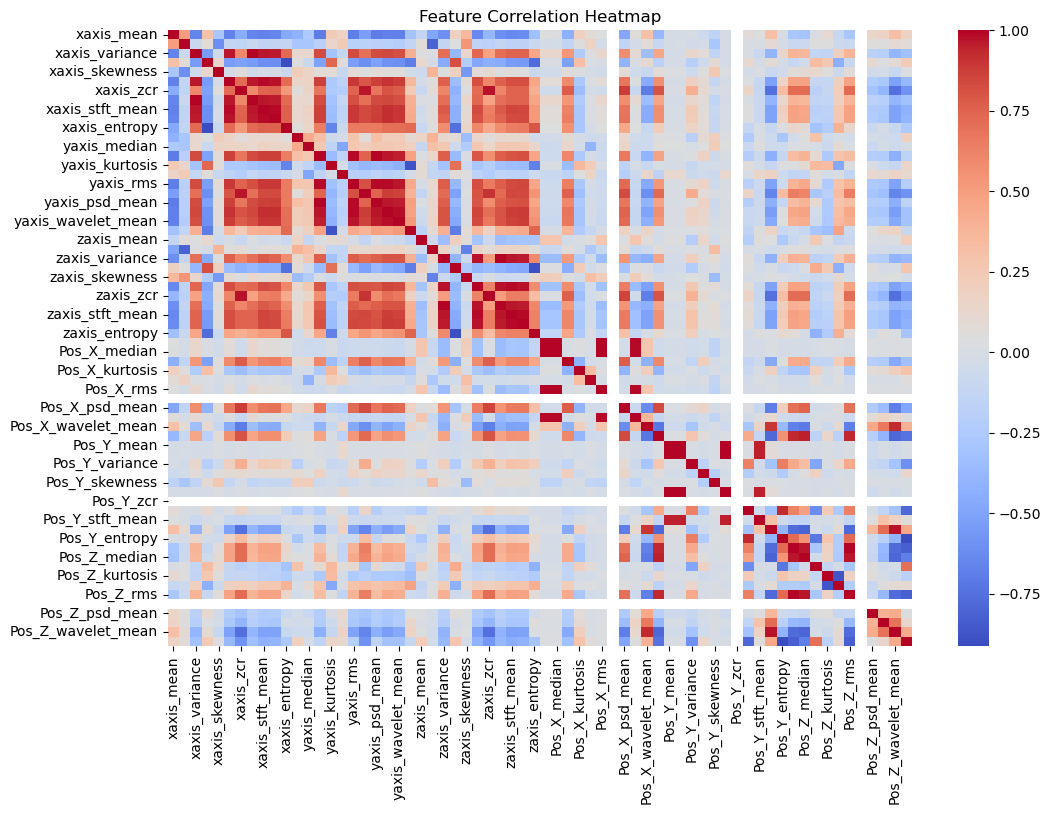

In [351]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [352]:
feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top Features by Importance:")
print(feature_importances.head(10))


Top Features by Importance:
               Feature  Importance
2       xaxis_variance    0.082363
7       xaxis_psd_mean    0.079149
8      xaxis_stft_mean    0.064200
13      yaxis_variance    0.061058
5            xaxis_rms    0.058541
9   xaxis_wavelet_mean    0.044855
16           yaxis_rms    0.040625
24      zaxis_variance    0.035751
0           xaxis_mean    0.033604
28           zaxis_zcr    0.032673


In [353]:
# Step 4: Split the data into training and test sets
train_set, test_set = train_test_split(combined_features, test_size=0.2, random_state=42, stratify=y)

X_train = train_set.drop(columns=['Label'])
y_train = train_set['Label']
X_test = test_set.drop(columns=['Label'])
y_test = test_set['Label']




In [354]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)


In [355]:
print("Class Distribution in Labels:")
print(y_train.value_counts())

Class Distribution in Labels:
1    370
0    273
Name: Label, dtype: int64


In [356]:
# Step 5: Train Random Forest Classifier
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [357]:
# Step 6: Evaluate the model
print(f"Training Accuracy: {rf_model.score(X_train, y_train):.2f}")
print(f"Testing Accuracy: {rf_model.score(X_test, y_test):.2f}")

Training Accuracy: 1.00
Testing Accuracy: 0.99


In [358]:
# Evaluate the model
from sklearn.metrics import classification_report
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Cross-validation to ensure robustness
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X, y, cv=5, scoring="accuracy")
print(f"Cross-Validation Accuracy: {np.mean(scores):.2f}")

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        54
           1       0.99      0.99      0.99       107

    accuracy                           0.99       161
   macro avg       0.99      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161

Cross-Validation Accuracy: 0.97


In [359]:
# List of features to keep
features_to_keep = [
    'xaxis_rms', 'yaxis_rms', 'zaxis_rms', 
    'Pos_X_rms', 'Pos_Y_rms', 'Pos_Z_rms', 
    'xaxis_mean', 'xaxis_variance', 'xaxis_skewness',
    'yaxis_mean', 'yaxis_variance', 'yaxis_skewness',
    'zaxis_mean', 'zaxis_variance', 'zaxis_skewness'
]

# Filter the dataset
X_reduced = X[features_to_keep]

# Check the reduced dataset
print(f"Reduced feature set: {X_reduced.columns}")


Reduced feature set: Index(['xaxis_rms', 'yaxis_rms', 'zaxis_rms', 'Pos_X_rms', 'Pos_Y_rms',
       'Pos_Z_rms', 'xaxis_mean', 'xaxis_variance', 'xaxis_skewness',
       'yaxis_mean', 'yaxis_variance', 'yaxis_skewness', 'zaxis_mean',
       'zaxis_variance', 'zaxis_skewness'],
      dtype='object')


In [360]:
# Step 4: Split the data into training and test sets
train_set, test_set = train_test_split(combined_features, test_size=0.2, random_state=42, stratify=y)

X_train = train_set.drop(columns=['Label'])
y_train = train_set['Label']
X_test = test_set.drop(columns=['Label'])
y_test = test_set['Label']


In [361]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [362]:
print("Class Distribution in Labels:")
print(y_train.value_counts())

Class Distribution in Labels:
1    370
0    273
Name: Label, dtype: int64


In [363]:
# Step 5: Train Random Forest Classifier
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [364]:
# Step 6: Evaluate the model
print(f"Training Accuracy: {rf_model.score(X_train, y_train):.2f}")
print(f"Testing Accuracy: {rf_model.score(X_test, y_test):.2f}")

Training Accuracy: 1.00
Testing Accuracy: 0.99


In [365]:
# Evaluate the model
from sklearn.metrics import classification_report
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Cross-validation to ensure robustness
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X, y, cv=5, scoring="accuracy")
print(f"Cross-Validation Accuracy: {np.mean(scores):.2f}")

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        54
           1       0.99      0.99      0.99       107

    accuracy                           0.99       161
   macro avg       0.99      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161

Cross-Validation Accuracy: 0.97


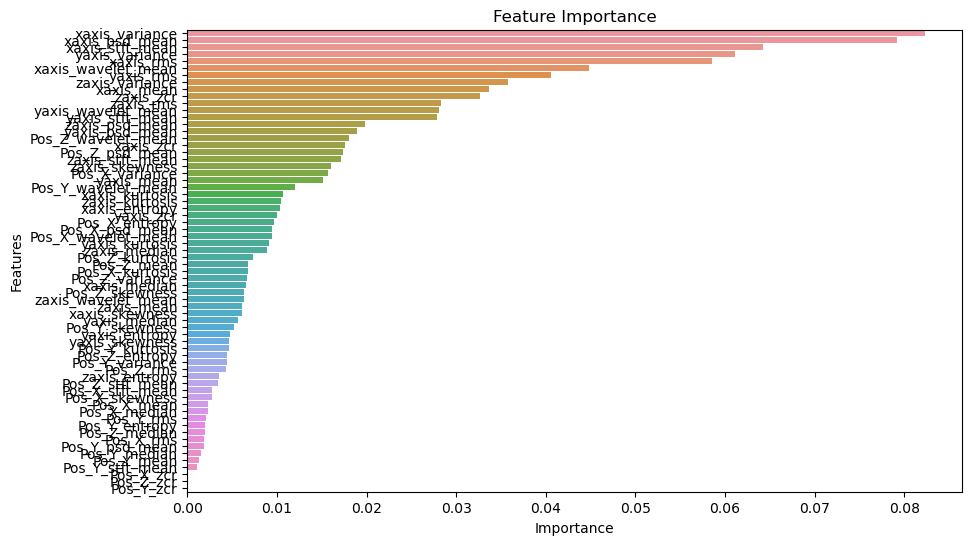

In [366]:
# Step 3: Visualization 1 - Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

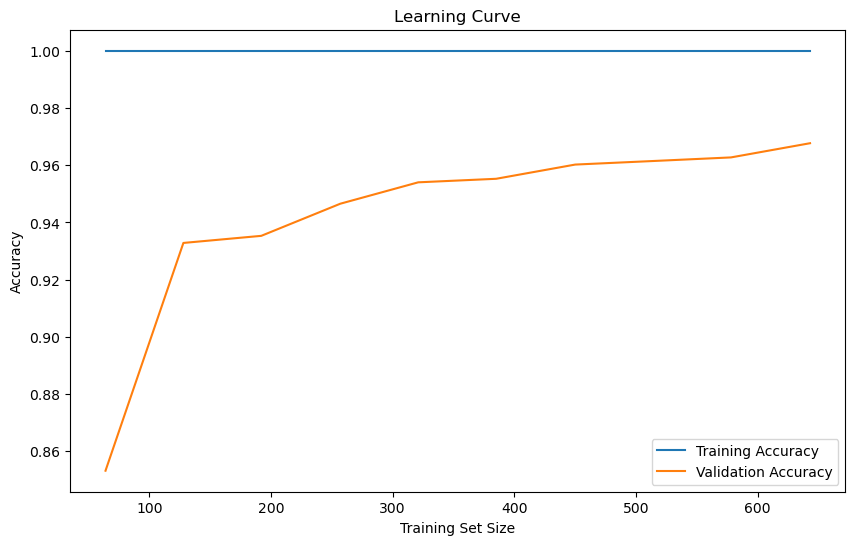

In [367]:
# Step 4: Visualization 2 - Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X, y, cv=5, scoring="accuracy", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()


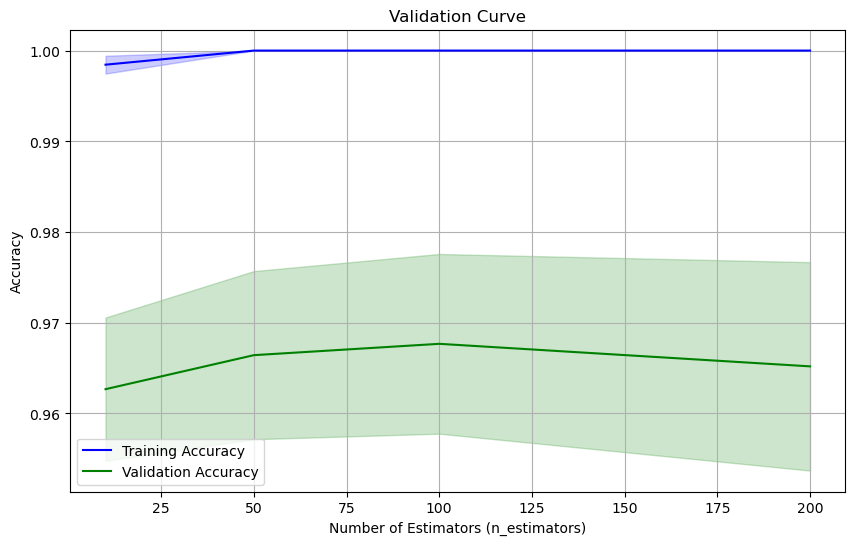

In [368]:
from sklearn.model_selection import validation_curve
import numpy as np
import matplotlib.pyplot as plt

# Step 5: Visualization 3 - Validation Curve
param_range = [10, 50, 100, 200]
train_scores, test_scores = validation_curve(
    rf_model, X, y, param_name="n_estimators", param_range=param_range, cv=5, scoring="accuracy", n_jobs=-1
)

# Compute mean and standard deviation of training and test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot Validation Curve
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Training Accuracy", color="blue")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.2)
plt.plot(param_range, test_mean, label="Validation Accuracy", color="green")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, color="green", alpha=0.2)
plt.title("Validation Curve")
plt.xlabel("Number of Estimators (n_estimators)")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()


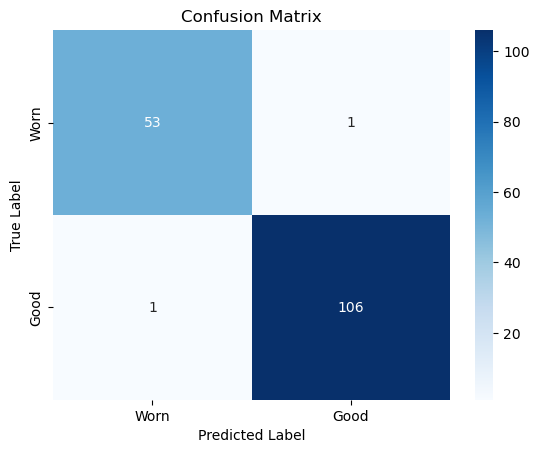

In [369]:
# Step 6: Visualization 4 - Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Worn", "Good"], yticklabels=["Worn", "Good"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

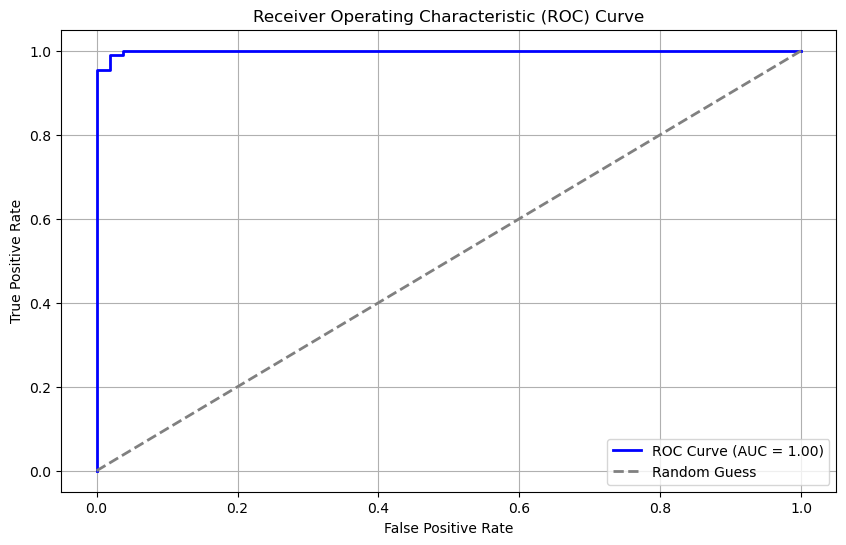

In [370]:
# Ensure the required imports
from sklearn.metrics import roc_curve, auc

if len(set(y_test)) == 2:  # Check if it's binary classification
    y_prob = rf_model.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()
else:
    print("ROC Curve cannot be plotted for non-binary classification.")


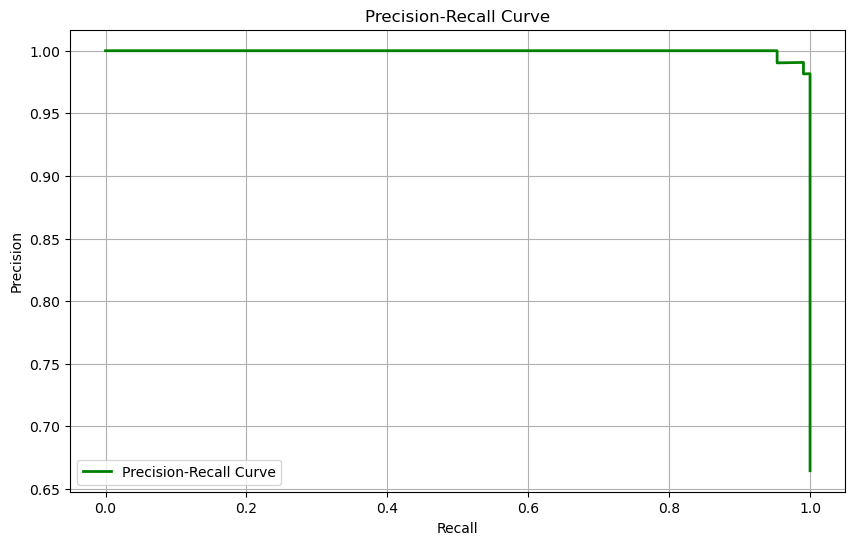

In [371]:
# Ensure the required imports
from sklearn.metrics import precision_recall_curve

# Generate the Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='green', lw=2, label="Precision-Recall Curve")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid()
plt.show()


In [372]:
# Manually introduce bad data (Label = 0) for testing
bad_data = combined_features[combined_features['Label'] == 0].sample(5, random_state=42)

# Predict conditions for bad data
bad_predictions = rf_model.predict(bad_data.drop(columns=['Label']))
bad_data['Predicted_Label'] = bad_predictions

# Check false predictions
false_positives = bad_data[bad_data['Predicted_Label'] == 1]  # Misclassified as good

print(f"False Positives:\n{false_positives}")


False Positives:
Empty DataFrame
Columns: [xaxis_mean, xaxis_median, xaxis_variance, xaxis_kurtosis, xaxis_skewness, xaxis_rms, xaxis_zcr, xaxis_psd_mean, xaxis_stft_mean, xaxis_wavelet_mean, xaxis_entropy, Label, yaxis_mean, yaxis_median, yaxis_variance, yaxis_kurtosis, yaxis_skewness, yaxis_rms, yaxis_zcr, yaxis_psd_mean, yaxis_stft_mean, yaxis_wavelet_mean, yaxis_entropy, zaxis_mean, zaxis_median, zaxis_variance, zaxis_kurtosis, zaxis_skewness, zaxis_rms, zaxis_zcr, zaxis_psd_mean, zaxis_stft_mean, zaxis_wavelet_mean, zaxis_entropy, Pos_X_mean, Pos_X_median, Pos_X_variance, Pos_X_kurtosis, Pos_X_skewness, Pos_X_rms, Pos_X_zcr, Pos_X_psd_mean, Pos_X_stft_mean, Pos_X_wavelet_mean, Pos_X_entropy, Pos_Y_mean, Pos_Y_median, Pos_Y_variance, Pos_Y_kurtosis, Pos_Y_skewness, Pos_Y_rms, Pos_Y_zcr, Pos_Y_psd_mean, Pos_Y_stft_mean, Pos_Y_wavelet_mean, Pos_Y_entropy, Pos_Z_mean, Pos_Z_median, Pos_Z_variance, Pos_Z_kurtosis, Pos_Z_skewness, Pos_Z_rms, Pos_Z_zcr, Pos_Z_psd_mean, Pos_Z_stft_mean, P

Training set: (562, 66)
Test set: (162, 66)
Validation set: (80, 66)
Test Set Performance:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        66
           1       0.96      0.98      0.97        96

    accuracy                           0.96       162
   macro avg       0.96      0.96      0.96       162
weighted avg       0.96      0.96      0.96       162

Validation Set Performance:
Accuracy: 0.95
Precision: 0.96
Recall: 0.96
F1-Score: 0.96
ROC-AUC: 0.99

Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        32
           1       0.96      0.96      0.96        48

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80

Confusion Matrix (Validation Set):
[[30  2]
 [ 2 46]]


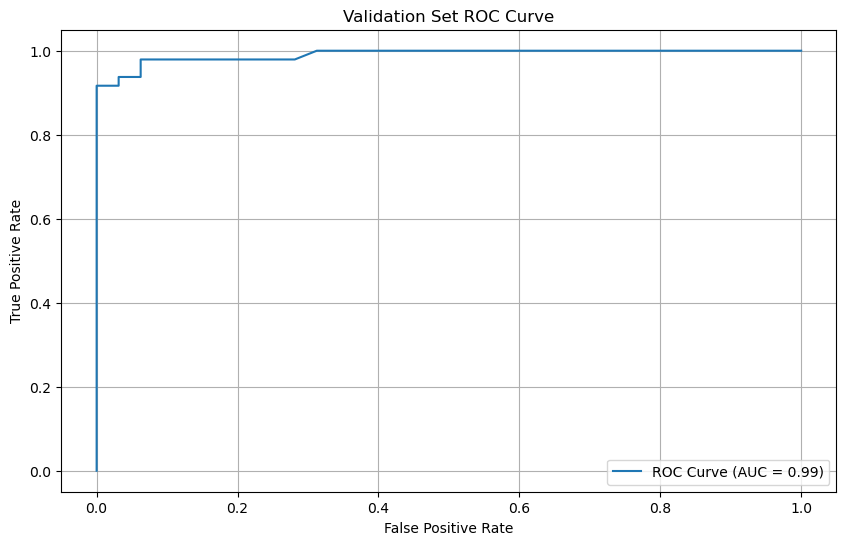

In [373]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils import shuffle

# Step 1: Shuffle and Split the Data
combined_features = shuffle(combined_features, random_state=42)

# Initial split: Train (70%) and Remaining (30%)
X = combined_features.drop(columns=["Label"])
y = combined_features["Label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: Test (20%) and Validation (10%) from the remaining 30%
X_test, X_valid, y_test, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.33, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Validation set: {X_valid.shape}")

# Step 2: Train the Model
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate on Test Set
print("Test Set Performance:")
y_test_pred = rf_model.predict(X_test)
y_test_prob = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_test_pred))

# Step 3: Evaluate on Validation Set
print("Validation Set Performance:")
y_valid_pred = rf_model.predict(X_valid)
y_valid_prob = rf_model.predict_proba(X_valid)[:, 1]

accuracy = accuracy_score(y_valid, y_valid_pred)
precision = precision_score(y_valid, y_valid_pred, zero_division=0)
recall = recall_score(y_valid, y_valid_pred, zero_division=0)
f1 = f1_score(y_valid, y_valid_pred, zero_division=0)
roc_auc = roc_auc_score(y_valid, y_valid_prob)

# Print validation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")

print("\nClassification Report (Validation Set):")
print(classification_report(y_valid, y_valid_pred))

# Confusion Matrix for Validation Set
conf_matrix = confusion_matrix(y_valid, y_valid_pred)
print("Confusion Matrix (Validation Set):")
print(conf_matrix)

# Save Validation Results
validation_results = pd.DataFrame({
    "True Label": y_valid,
    "Predicted Label": y_valid_pred,
    "Predicted Probability": y_valid_prob,
})
validation_results.to_csv("validation_results.csv", index=False)

# Optional: Plot ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_valid, y_valid_prob)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation Set ROC Curve")
plt.legend()
plt.grid()
plt.show()
